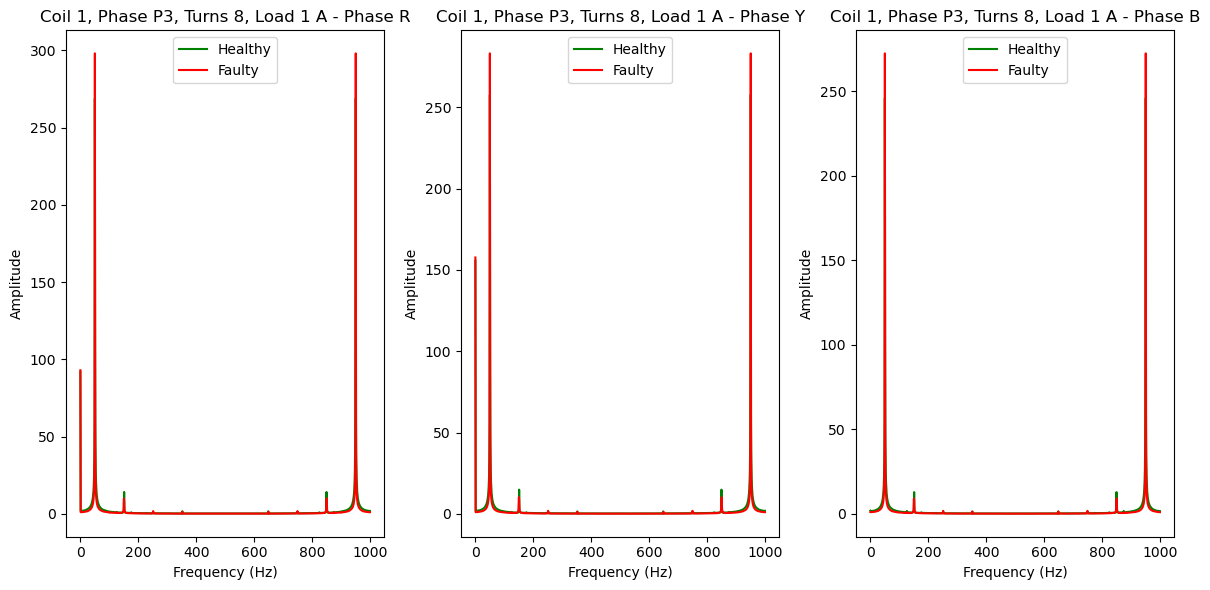

In [9]:
#THIS CODE IS ONLY FOR B PHASE FAULTS MANUALLY CHANGE EACH BLOCK OF CODE TO NECESSARY PHASE TO FIND FAULT OF THAT PHASE
#VISUALIZING VARIOUS R,Y,B FAULTS USNG FFT PLOTTING
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft

def load_and_process_file(file_path, segment_length=1000):
    """
    Load a file, split it into segments, and compute the FFT for each segment.
    """
    try:
        # Load the CSV file
        df = pd.read_csv(file_path, header=None)
        current_data = df.iloc[:, -3:].values  # Take the last 3 columns (R, Y, B currents)

        # Split into 1-second segments (1000 samples per segment)
        segments = [current_data[i:i + segment_length] for i in range(0, len(current_data), segment_length) if i + segment_length <= len(current_data)]

        # Compute FFT for each segment and average the results
        fft_results = []
        for segment in segments:
            fft_result = np.abs(fft(segment, axis=0))  # Compute FFT for each phase
            fft_results.append(fft_result)
        avg_fft = np.mean(fft_results, axis=0)  # Average FFT across segments

        return avg_fft

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
        return None

def plot_fft_comparison(healthy_fft, faulty_fft, title):
    """
    Plot the FFTs for healthy and faulty conditions on the same graph.
    """
    plt.figure(figsize=(12, 6))
    for i, phase in enumerate(['R', 'Y', 'B']):
        plt.subplot(1, 3, i + 1)
        plt.plot(healthy_fft[:, i], label='Healthy', color='green')
        plt.plot(faulty_fft[:, i], label='Faulty', color='red')
        plt.title(f'{title} - Phase {phase}')
        plt.xlabel('Frequency (Hz)')
        plt.ylabel('Amplitude')
        plt.legend()
    plt.tight_layout()
    plt.show()

def visualize_fft_comparison(base_dir, coil, phase, turns, load):
    """
    Visualize FFT comparison for healthy and faulty conditions.
    """
    # Construct file paths
    faulty_file = '/home/ani/DataNN/5kVA/Load/0.5_A/Fault/P3/5_F36.csv'
    healthy_file = '/home/ani/DataNN/5kVA/Load/0.5_A/No_Fault/No_F36.csv'

    # Load and process files
    healthy_fft = load_and_process_file(healthy_file)
    faulty_fft = load_and_process_file(faulty_file)

    if healthy_fft is not None and faulty_fft is not None:
        # Plot FFT comparison
        title = f"Coil {coil}, Phase {phase}, Turns {turns}, Load {load} A"
        plot_fft_comparison(healthy_fft, faulty_fft, title)

# Directory path to data
base_dir = "/home/ani/DataNN/5kVA/Load"

# Example: Visualize FFT comparison for Coil 1, Phase P1 (R), Turns 8, Load 1 A
visualize_fft_comparison(base_dir, coil=1, phase="P3", turns=8, load=1)

In [10]:
#CNN WITH LIMITED EPOCHS
import os
import numpy as np
import pandas as pd
from scipy.fft import fft
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Flatten
from sklearn.metrics import classification_report

def process_file(file_path, data_segments, labels, label, segment_count, segment_length=1000):
    """
    Process a single file: split into segments, apply FFT, and assign labels.
    """
    try:
        # Load the CSV file
        df = pd.read_csv(file_path, header=None)
        current_data = df.iloc[:, -3:].values  # Take the last 3 columns (R, Y, B currents)

        # Split into 1-second segments (1000 samples per segment)
        segments = [current_data[i:i + segment_length] for i in range(0, len(current_data), segment_length) if i + segment_length <= len(current_data)]

        # Perform FFT on each segment and keep the shape as (segment_length, 3)
        for segment in segments:
            fft_result = np.abs(fft(segment, axis=0))  # Apply FFT to each phase (R, Y, B)
            data_segments.append(fft_result)  # Shape: (segment_length, 3)
            labels.append(label)
            segment_count[label] += 1  # Increment the count for the respective label

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
    
    return data_segments, labels, segment_count

def load_and_preprocess_data(data_dir, segment_length=1000):
    """
    Load and preprocess data from the directory.
    """
    data_segments = []
    labels = []
    segment_count = {0: 0, 1: 0}  # Count of segments for No_Fault (0) and Fault (1)
    file_count = 0  # Initialize file counter

    # Iterate over load levels (e.g., 0.5_A, 1_A, etc.)
    for load in os.listdir(data_dir):
        load_path = os.path.join(data_dir, load)
        if not os.path.isdir(load_path):
            continue

        # Check for Fault and No_Fault directories
        for condition in ["Fault", "No_Fault"]:
            condition_path = os.path.join(load_path, condition)
            if condition == "Fault":  # Handle fault conditions
                for phase in ["P3"]:  # Only process P1 for this NN
                    phase_path = os.path.join(condition_path, phase)
                    if os.path.exists(phase_path):
                        for file in os.listdir(phase_path):
                            if file.endswith(".csv"):
                                file_count += 1  # Increment the file counter
                                file_path = os.path.join(phase_path, file)
                                data_segments, labels, segment_count = process_file(file_path, data_segments, labels, label=1, segment_count=segment_count, segment_length=segment_length)
            elif condition == "No_Fault":  # Handle no fault conditions
                if os.path.exists(condition_path):
                    for file in os.listdir(condition_path):
                        if file.endswith(".csv"):
                            file_count += 1  # Increment the file counter
                            file_path = os.path.join(condition_path, file)
                            data_segments, labels, segment_count = process_file(file_path, data_segments, labels, label=0, segment_count=segment_count, segment_length=segment_length)

    print(f"Total files processed: {file_count}")  # Print the total file count
    print(f"Total FFT segments for Fault: {segment_count[1]}")
    print(f"Total FFT segments for No Fault: {segment_count[0]}")
    return np.array(data_segments), np.array(labels)

# Directory path to data
base_dir = "/home/ani/DataNN/5kVA/Load"

# Load and preprocess data with 1-second intervals (1000 samples per segment)
segment_length = 1000  # Change to 500 if you want 500 samples per segment
data, labels = load_and_preprocess_data(base_dir, segment_length=segment_length)

# Check if data was loaded
if data.size == 0:
    print("No data found! Check the directory structure and file paths.")
    exit()

# Normalize data
data = (data - np.min(data)) / (np.max(data) - np.min(data))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

# Print training and testing FFT segment counts
print(f"Training FFT segments: {len(X_train)}")
print(f"Testing FFT segments: {len(X_test)}")

# Define the input
inputs = Input(shape=(segment_length, 3))  # Input shape: (segment_length, 3)

# Add layers
x = Flatten()(inputs)  # Flatten the input to pass to Dense layers
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(1, activation='sigmoid')(x)  # Binary classification

# Create the model
model = Model(inputs=inputs, outputs=outputs)

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Display model summary
print("\nModel Summary:")
model.summary()

# Additional evaluation
y_pred = (model.predict(X_test) > 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Total files processed: 720
Total FFT segments for Fault: 4320
Total FFT segments for No Fault: 2880
Training FFT segments: 5760
Testing FFT segments: 1440
Epoch 1/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5866 - loss: 0.6696 - val_accuracy: 0.5955 - val_loss: 0.6085
Epoch 2/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6676 - loss: 0.5742 - val_accuracy: 0.7335 - val_loss: 0.4962
Epoch 3/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7253 - loss: 0.5178 - val_accuracy: 0.7509 - val_loss: 0.4675
Epoch 4/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7775 - loss: 0.4705 - val_accuracy: 0.8212 - val_loss: 0.4251
Epoch 5/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8157 - loss: 0.4261 - val_accuracy: 0.8741 - val_loss: 0.3584
Epoch 6/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8226 - loss: 0.4074 - val_accuracy: 0.8455 - val_loss: 0.3262
Epoch 7/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8651 - loss

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 1000, 3)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 3000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │       384,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,177,349 (4.49 MB)

 Trainable params: 392,449 (1.50 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 784,900 (2.99 MB)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 745us/step

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.91      0.94       568
           1       0.94      0.99      0.96       872

    accuracy                           0.96      1440
   macro avg       0.96      0.95      0.95      1440
weighted avg       0.96      0.96      0.96      1440



Total files processed: 720
Total FFT segments for Fault: 4320
Total FFT segments for No Fault: 2880
Training FFT segments: 5760
Testing FFT segments: 1440
Class 0 (Healthy) samples: 2880
Class 1 (Faulty) samples: 4320
Epoch 1/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7189 - loss: 0.5597 - val_accuracy: 0.8967 - val_loss: 0.2772
Epoch 2/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9272 - loss: 0.2170 - val_accuracy: 0.9766 - val_loss: 0.1171
Epoch 3/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9575 - loss: 0.1507 - val_accuracy: 0.9783 - val_loss: 0.0856
Epoch 4/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9668 - loss: 0.1221 - val_accuracy: 0.9809 - val_loss: 0.0737
Epoch 5/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9656 - loss: 0.1207 - val_accuracy: 0.9661 - val_loss: 0.1057
Epoch 6/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9755 - loss: 0.0905 - val_accuracy: 0.9870 - val_loss: 0.0519
Epoch 7/50
144

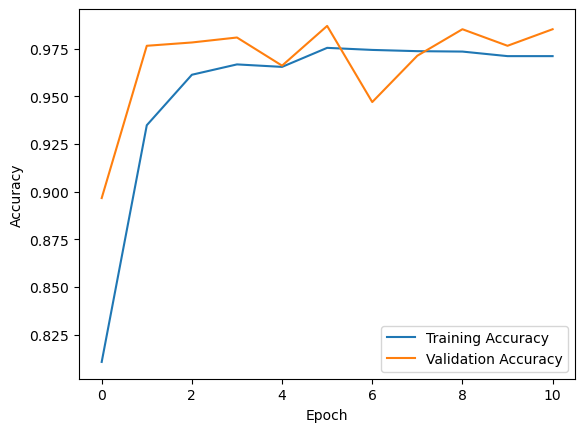

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 1000, 3)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 1000, 128)      │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 1000, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 1000, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 1000, 64)       │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 1000, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 1000, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 64000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │     2,048,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,248,325 (23.84 MB)

 Trainable params: 2,082,625 (7.94 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 4,165,252 (15.89 MB)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       568
           1       0.99      0.98      0.99       872

    accuracy                           0.99      1440
   macro avg       0.98      0.99      0.99      1440
weighted avg       0.99      0.99      0.99      1440



In [11]:
#IMPLEMENTING NORMALIZATION OF DATA WITH HIGHER EPOCHS AND EARLY STOPPING
import os
import numpy as np
import pandas as pd
from scipy.fft import fft
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, Dropout, Dense, Flatten, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

def process_file(file_path, data_segments, labels, label, segment_count, segment_length=1000):
    """
    Process a single file: split into segments, apply FFT, and assign labels.
    """
    try:
        # Load the CSV file
        df = pd.read_csv(file_path, header=None)
        current_data = df.iloc[:, -3:].values  # Take the last 3 columns (R, Y, B currents)

        # Split into 1-second segments (1000 samples per segment)
        segments = [current_data[i:i + segment_length] for i in range(0, len(current_data), segment_length) if i + segment_length <= len(current_data)]

        # Perform FFT on each segment and keep the shape as (segment_length, 3)
        for segment in segments:
            fft_result = np.abs(fft(segment, axis=0))  # Apply FFT to each phase (R, Y, B)
            data_segments.append(fft_result)  # Shape: (segment_length, 3)
            labels.append(label)
            segment_count[label] += 1  # Increment the count for the respective label

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
    
    return data_segments, labels, segment_count

def load_and_preprocess_data(data_dir, segment_length=1000):
    """
    Load and preprocess data from the directory.
    """
    data_segments = []
    labels = []
    segment_count = {0: 0, 1: 0}  # Count of segments for No_Fault (0) and Fault (1)
    file_count = 0  # Initialize file counter

    # Iterate over load levels (e.g., 0.5_A, 1_A, etc.)
    for load in os.listdir(data_dir):
        load_path = os.path.join(data_dir, load)
        if not os.path.isdir(load_path):
            continue

        # Check for Fault and No_Fault directories
        for condition in ["Fault", "No_Fault"]:
            condition_path = os.path.join(load_path, condition)
            if condition == "Fault":  # Handle fault conditions
                for phase in ["P3"]:  # Only process P1 for this NN
                    phase_path = os.path.join(condition_path, phase)
                    if os.path.exists(phase_path):
                        for file in os.listdir(phase_path):
                            if file.endswith(".csv"):
                                file_count += 1  # Increment the file counter
                                file_path = os.path.join(phase_path, file)
                                data_segments, labels, segment_count = process_file(file_path, data_segments, labels, label=1, segment_count=segment_count, segment_length=segment_length)
            elif condition == "No_Fault":  # Handle no fault conditions
                if os.path.exists(condition_path):
                    for file in os.listdir(condition_path):
                        if file.endswith(".csv"):
                            file_count += 1  # Increment the file counter
                            file_path = os.path.join(condition_path, file)
                            data_segments, labels, segment_count = process_file(file_path, data_segments, labels, label=0, segment_count=segment_count, segment_length=segment_length)

    print(f"Total files processed: {file_count}")  # Print the total file count
    print(f"Total FFT segments for Fault: {segment_count[1]}")
    print(f"Total FFT segments for No Fault: {segment_count[0]}")
    return np.array(data_segments), np.array(labels)

# Directory path to data
base_dir = "/home/ani/DataNN/5kVA/Load"

# Load and preprocess data with 1-second intervals (1000 samples per segment)
segment_length = 1000  # Change to 500 if you want 500 samples per segment
data, labels = load_and_preprocess_data(base_dir, segment_length=segment_length)

# Check if data was loaded
if data.size == 0:
    print("No data found! Check the directory structure and file paths.")
    exit()

# Normalize data
#data = (data - np.min(data)) / (np.max(data) - np.min(data))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

# Print training and testing FFT segment counts
print(f"Training FFT segments: {len(X_train)}")
print(f"Testing FFT segments: {len(X_test)}")

# Check class distribution
print(f"Class 0 (Healthy) samples: {np.sum(labels == 0)}")
print(f"Class 1 (Faulty) samples: {np.sum(labels == 1)}")

# Define the CNN model with a bottleneck layer
def build_cnn_model(input_shape):
    inputs = Input(shape=input_shape)

    # Convolutional layers
    x = Conv1D(128, kernel_size=3, padding='same', activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Increased dropout rate

    x = Conv1D(64, kernel_size=4, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Increased dropout rate

    x = Flatten()(x)

    # Bottleneck layer
    x = Dense(32)(x)  # Bottleneck size = 32
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Increased dropout rate
    x = Activation('relu')(x)

    # Output layer
    outputs = Dense(1, activation='sigmoid')(x)  # Binary classification

    # Create the model
    model = Model(inputs=inputs, outputs=outputs)
    return model

# Build the model
input_shape = (segment_length, 3)  # Input shape: (segment_length, 3)
cnn_model = build_cnn_model(input_shape)

# Compile the model
cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Add early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model with early stopping
history = cnn_model.fit(
    X_train, y_train,
    epochs=50,  # Increased epochs
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping]
)

# Evaluate the model
loss, accuracy = cnn_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Plot training history
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
cnn_model.summary()
# Additional evaluation
y_pred = (cnn_model.predict(X_test) > 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Total files processed: 720
Total FFT segments for Fault: 4320
Total FFT segments for No Fault: 2880
Training FFT segments: 5760
Testing FFT segments: 1440
Class 0 (Healthy) samples: 2880
Class 1 (Faulty) samples: 4320
Epoch 1/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6228 - loss: 0.6488 - val_accuracy: 0.5920 - val_loss: 0.6953
Epoch 2/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8354 - loss: 0.3628 - val_accuracy: 0.8273 - val_loss: 0.6294
Epoch 3/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9099 - loss: 0.2259 - val_accuracy: 0.6606 - val_loss: 0.5963
Epoch 4/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9284 - loss: 0.1776 - val_accuracy: 0.5920 - val_loss: 0.6861
Epoch 5/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9433 - loss: 0.1481 - val_accuracy: 0.9566 - val_loss: 0.1636
Epoch 6/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9450 - loss: 0.1533 - val_accuracy: 0.9549 - val_loss: 0.1532
Epoch 7/50
144

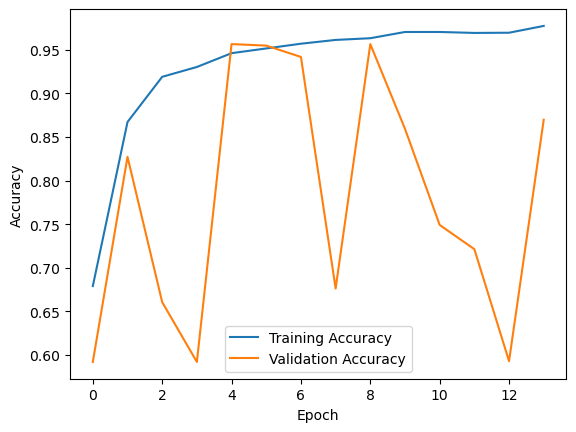

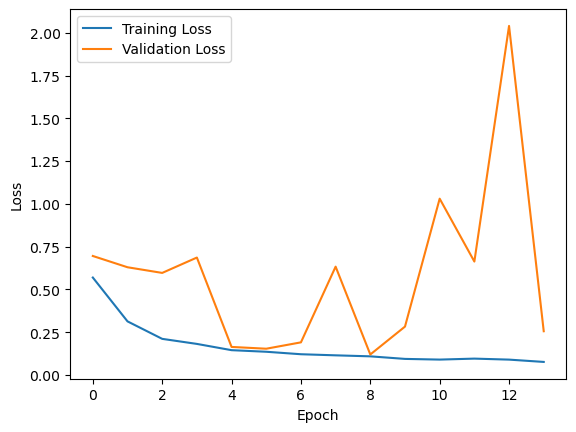

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 1000, 3)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 1000, 128)      │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 1000, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 1000, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 1000, 64)       │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 1000, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 1000, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 64000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │     2,048,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,248,325 (23.84 MB)

 Trainable params: 2,082,625 (7.94 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 4,165,252 (15.89 MB)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.88      0.93       568
           1       0.93      0.99      0.96       872

    accuracy                           0.95      1440
   macro avg       0.96      0.94      0.94      1440
weighted avg       0.95      0.95      0.95      1440



In [12]:
#IMPLEMENTING WEIGHTS FOR IMBALANCED DATA
import os
import numpy as np
import pandas as pd
from scipy.fft import fft
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, Dropout, Dense, Flatten, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

def process_file(file_path, data_segments, labels, label, segment_count, segment_length=1000):
    """
    Process a single file: split into segments, apply FFT, and assign labels.
    """
    try:
        # Load the CSV file
        df = pd.read_csv(file_path, header=None)
        current_data = df.iloc[:, -3:].values  # Take the last 3 columns (R, Y, B currents)

        # Split into 1-second segments (1000 samples per segment)
        segments = [current_data[i:i + segment_length] for i in range(0, len(current_data), segment_length) if i + segment_length <= len(current_data)]

        # Perform FFT on each segment and keep the shape as (segment_length, 3)
        for segment in segments:
            fft_result = np.abs(fft(segment, axis=0))  # Apply FFT to each phase (R, Y, B)
            data_segments.append(fft_result)  # Shape: (segment_length, 3)
            labels.append(label)
            segment_count[label] += 1  # Increment the count for the respective label

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
    
    return data_segments, labels, segment_count

def load_and_preprocess_data(data_dir, segment_length=1000):
    """
    Load and preprocess data from the directory.
    """
    data_segments = []
    labels = []
    segment_count = {0: 0, 1: 0}  # Count of segments for No_Fault (0) and Fault (1)
    file_count = 0  # Initialize file counter

    # Iterate over load levels (e.g., 0.5_A, 1_A, etc.)
    for load in os.listdir(data_dir):
        load_path = os.path.join(data_dir, load)
        if not os.path.isdir(load_path):
            continue

        # Check for Fault and No_Fault directories
        for condition in ["Fault", "No_Fault"]:
            condition_path = os.path.join(load_path, condition)
            if condition == "Fault":  # Handle fault conditions
                for phase in ["P3"]:  # Only process P1 for this NN
                    phase_path = os.path.join(condition_path, phase)
                    if os.path.exists(phase_path):
                        for file in os.listdir(phase_path):
                            if file.endswith(".csv"):
                                file_count += 1  # Increment the file counter
                                file_path = os.path.join(phase_path, file)
                                data_segments, labels, segment_count = process_file(file_path, data_segments, labels, label=1, segment_count=segment_count, segment_length=segment_length)
            elif condition == "No_Fault":  # Handle no fault conditions
                if os.path.exists(condition_path):
                    for file in os.listdir(condition_path):
                        if file.endswith(".csv"):
                            file_count += 1  # Increment the file counter
                            file_path = os.path.join(condition_path, file)
                            data_segments, labels, segment_count = process_file(file_path, data_segments, labels, label=0, segment_count=segment_count, segment_length=segment_length)

    print(f"Total files processed: {file_count}")  # Print the total file count
    print(f"Total FFT segments for Fault: {segment_count[1]}")
    print(f"Total FFT segments for No Fault: {segment_count[0]}")
    return np.array(data_segments), np.array(labels)

# Directory path to data
base_dir = "/home/ani/DataNN/5kVA/Load"

# Load and preprocess data with 1-second intervals (1000 samples per segment)
segment_length = 1000  # Change to 500 if you want 500 samples per segment
data, labels = load_and_preprocess_data(base_dir, segment_length=segment_length)

# Check if data was loaded
if data.size == 0:
    print("No data found! Check the directory structure and file paths.")
    exit()

# Normalize data
data = (data - np.min(data)) / (np.max(data) - np.min(data))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

# Print training and testing FFT segment counts
print(f"Training FFT segments: {len(X_train)}")
print(f"Testing FFT segments: {len(X_test)}")

# Check class distribution
print(f"Class 0 (Healthy) samples: {np.sum(labels == 0)}")
print(f"Class 1 (Faulty) samples: {np.sum(labels == 1)}")

# Define the CNN model with a bottleneck layer
def build_cnn_model(input_shape):
    inputs = Input(shape=input_shape)

    # Convolutional layers
    x = Conv1D(128, kernel_size=3, padding='same', activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting

    x = Conv1D(64, kernel_size=4, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting

    x = Flatten()(x)

    # Bottleneck layer
    x = Dense(32)(x)  # Bottleneck size = 32
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting
    x = Activation('relu')(x)

    # Output layer
    outputs = Dense(1, activation='sigmoid')(x)  # Binary classification

    # Create the model
    model = Model(inputs=inputs, outputs=outputs)
    return model

# Build the model
input_shape = (segment_length, 3)  # Input shape: (segment_length, 3)
cnn_model = build_cnn_model(input_shape)

# Compile the model
cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Add early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Add class weighting to address imbalance
class_weights = {0: 1.2, 1: 0.8}  # Adjust weights based on class imbalance

# Train the model with early stopping and class weighting
history = cnn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    class_weight=class_weights
)

# Evaluate the model
loss, accuracy = cnn_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
cnn_model.summary()
# Additional evaluation
y_pred = (cnn_model.predict(X_test) > 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Total files processed: 720
Total FFT segments for Fault: 4320
Total FFT segments for No Fault: 2880
Training FFT segments: 5760
Testing FFT segments: 1440
Class 0 (Healthy) samples in training: 2304
Class 1 (Faulty) samples in training: 3456
Class 0 (Healthy) samples in testing: 576
Class 1 (Faulty) samples in testing: 864
Epoch 1/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7425 - loss: 0.5765 - val_accuracy: 0.8082 - val_loss: 0.3910
Epoch 2/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9260 - loss: 0.2083 - val_accuracy: 0.8958 - val_loss: 0.2450
Epoch 3/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9429 - loss: 0.1524 - val_accuracy: 0.9253 - val_loss: 0.1824
Epoch 4/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9537 - loss: 0.1263 - val_accuracy: 0.9800 - val_loss: 0.0811
Epoch 5/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9544 - loss: 0.1333 - val_accuracy: 0.9783 - val_loss: 0.0760
Epoch 6/50
144/144 ━━━━━━━━━━━━━━━━

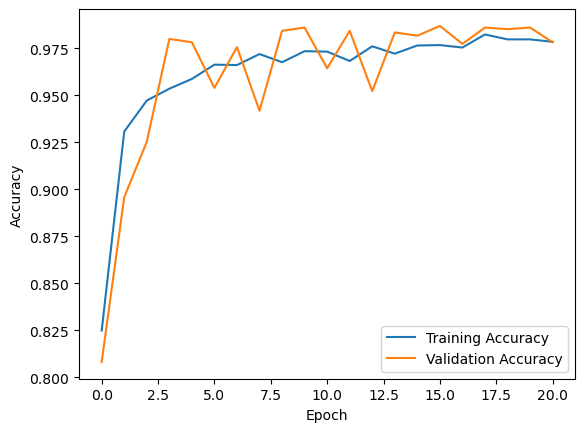

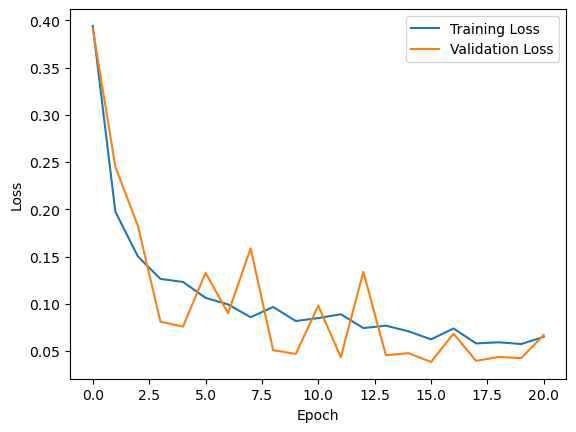

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 1000, 3)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_12 (Conv1D)              │ (None, 1000, 128)      │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 1000, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 1000, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 1000, 64)       │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 1000, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 1000, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 64000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │     2,048,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,248,325 (23.84 MB)

 Trainable params: 2,082,625 (7.94 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 4,165,252 (15.89 MB)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       576
           1       1.00      0.98      0.99       864

    accuracy                           0.98      1440
   macro avg       0.98      0.99      0.98      1440
weighted avg       0.99      0.98      0.98      1440



In [13]:
#TRAINING OF THE CONVOLUTIONAL NN MODEL SEPARATED TRAINTESTSPLIT FOR FAULT NO FAULT
import os
import numpy as np
import pandas as pd
from scipy.fft import fft
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, Dropout, Dense, Flatten, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

def process_file(file_path, data_segments, labels, label, segment_length=1000):
    """
    Process a single file: split into segments, apply FFT, and assign labels.
    """
    try:
        # Load the CSV file
        df = pd.read_csv(file_path, header=None)
        current_data = df.iloc[:, -3:].values  # Take the last 3 columns (R, Y, B currents)

        # Split into 1-second segments (1000 samples per segment)
        segments = [current_data[i:i + segment_length] for i in range(0, len(current_data), segment_length) if i + segment_length <= len(current_data)]

        # Perform FFT on each segment and keep the shape as (segment_length, 3)
        for segment in segments:
            fft_result = np.abs(fft(segment, axis=0))  # Apply FFT to each phase (R, Y, B)
            data_segments.append(fft_result)  # Shape: (segment_length, 3)
            labels.append(label)

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
    
    return data_segments, labels

def load_and_preprocess_data(data_dir, segment_length=1000, test_size=0.2, random_state=42):
    """
    Load and preprocess data from the directory, splitting fault and no-fault data separately.
    """
    fault_data = []
    no_fault_data = []
    fault_labels = []
    no_fault_labels = []
    file_count = 0  # Initialize file counter

    # Iterate over load levels (e.g., 0.5_A, 1_A, etc.)
    for load in os.listdir(data_dir):
        load_path = os.path.join(data_dir, load)
        if not os.path.isdir(load_path):
            continue

        # Check for Fault and No_Fault directories
        for condition in ["Fault", "No_Fault"]:
            condition_path = os.path.join(load_path, condition)
            if condition == "Fault":  # Handle fault conditions
                for phase in ["P3"]:  # Only process P1 for this NN
                    phase_path = os.path.join(condition_path, phase)
                    if os.path.exists(phase_path):
                        for file in os.listdir(phase_path):
                            if file.endswith(".csv"):
                                file_count += 1  # Increment the file counter
                                file_path = os.path.join(phase_path, file)
                                fault_data, fault_labels = process_file(file_path, fault_data, fault_labels, label=1, segment_length=segment_length)
            elif condition == "No_Fault":  # Handle no fault conditions
                if os.path.exists(condition_path):
                    for file in os.listdir(condition_path):
                        if file.endswith(".csv"):
                            file_count += 1  # Increment the file counter
                            file_path = os.path.join(condition_path, file)
                            no_fault_data, no_fault_labels = process_file(file_path, no_fault_data, no_fault_labels, label=0, segment_length=segment_length)

    print(f"Total files processed: {file_count}")  # Print the total file count
    print(f"Total FFT segments for Fault: {len(fault_data)}")
    print(f"Total FFT segments for No Fault: {len(no_fault_data)}")

    # Convert to numpy arrays
    fault_data = np.array(fault_data)
    no_fault_data = np.array(no_fault_data)
    fault_labels = np.array(fault_labels)
    no_fault_labels = np.array(no_fault_labels)

    # Split fault data into train and test sets
    X_fault_train, X_fault_test, y_fault_train, y_fault_test = train_test_split(
        fault_data, fault_labels, test_size=test_size, random_state=random_state
    )

    # Split no-fault data into train and test sets
    X_no_fault_train, X_no_fault_test, y_no_fault_train, y_no_fault_test = train_test_split(
        no_fault_data, no_fault_labels, test_size=test_size, random_state=random_state
    )

    # Combine fault and no-fault data
    X_train = np.concatenate((X_fault_train, X_no_fault_train), axis=0)
    X_test = np.concatenate((X_fault_test, X_no_fault_test), axis=0)
    y_train = np.concatenate((y_fault_train, y_no_fault_train), axis=0)
    y_test = np.concatenate((y_fault_test, y_no_fault_test), axis=0)

    # Shuffle the training and testing data
    train_indices = np.arange(len(X_train))
    test_indices = np.arange(len(X_test))
    np.random.shuffle(train_indices)
    np.random.shuffle(test_indices)

    X_train = X_train[train_indices]
    y_train = y_train[train_indices]
    X_test = X_test[test_indices]
    y_test = y_test[test_indices]

    return X_train, X_test, y_train, y_test

# Directory path to data
base_dir = "/home/ani/DataNN/5kVA/Load"

# Load and preprocess data with 1-second intervals (1000 samples per segment)
segment_length = 1000  # Change to 500 if you want 500 samples per segment
X_train, X_test, y_train, y_test = load_and_preprocess_data(base_dir, segment_length=segment_length)

# Check if data was loaded
if X_train.size == 0 or X_test.size == 0:
    print("No data found! Check the directory structure and file paths.")
    exit()

# Print training and testing FFT segment counts
print(f"Training FFT segments: {len(X_train)}")
print(f"Testing FFT segments: {len(X_test)}")

# Check class distribution
print(f"Class 0 (Healthy) samples in training: {np.sum(y_train == 0)}")
print(f"Class 1 (Faulty) samples in training: {np.sum(y_train == 1)}")
print(f"Class 0 (Healthy) samples in testing: {np.sum(y_test == 0)}")
print(f"Class 1 (Faulty) samples in testing: {np.sum(y_test == 1)}")

# Define the CNN model with a bottleneck layer
def build_cnn_model(input_shape):
    inputs = Input(shape=input_shape)

    # Convolutional layers
    x = Conv1D(128, kernel_size=3, padding='same', activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting

    x = Conv1D(64, kernel_size=4, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting

    x = Flatten()(x)

    # Bottleneck layer
    x = Dense(32)(x)  # Bottleneck size = 32
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting
    x = Activation('relu')(x)

    # Output layer
    outputs = Dense(1, activation='sigmoid')(x)  # Binary classification

    # Create the model
    model = Model(inputs=inputs, outputs=outputs)
    return model

# Build the model
input_shape = (segment_length, 3)  # Input shape: (segment_length, 3)
cnn_model = build_cnn_model(input_shape)

# Compile the model
cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Add early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Add class weighting to address imbalance
class_weights = {0: 1.2, 1: 0.8}  # Adjust weights based on class imbalance

# Train the model with early stopping and class weighting
history = cnn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    class_weight=class_weights
)

# Evaluate the model
loss, accuracy = cnn_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
cnn_model.summary()
# Additional evaluation
y_pred = (cnn_model.predict(X_test) > 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Total files processed: 720
Total FFT segments for Fault: 4320
Total FFT segments for No Fault: 2880
Training FFT segments: 5760
Testing FFT segments: 648
Class 0 (Healthy) samples in training: 2304
Class 1 (Faulty) samples in training: 3456
Class 0 (Healthy) samples in testing: 576
Class 1 (Faulty) samples in testing: 72
Epoch 1/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7592 - loss: 0.4971 - val_accuracy: 0.8177 - val_loss: 0.4051
Epoch 2/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9270 - loss: 0.2104 - val_accuracy: 0.9505 - val_loss: 0.1525
Epoch 3/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9569 - loss: 0.1371 - val_accuracy: 0.9444 - val_loss: 0.1708
Epoch 4/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9665 - loss: 0.1069 - val_accuracy: 0.9444 - val_loss: 0.1728
Epoch 5/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9648 - loss: 0.1108 - val_accuracy: 0.9184 - val_loss: 0.2085
Epoch 6/50
144/144 ━━━━━━━━━━━━━━━━━━

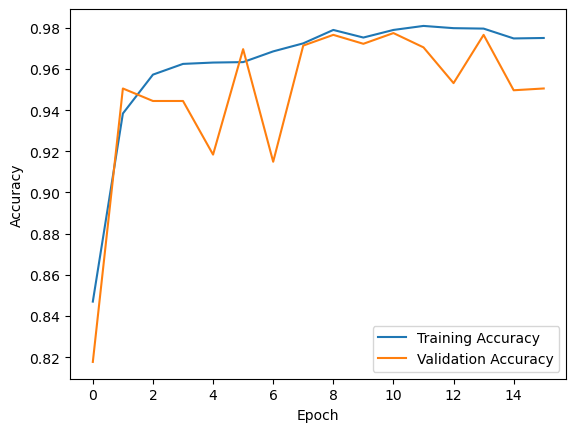

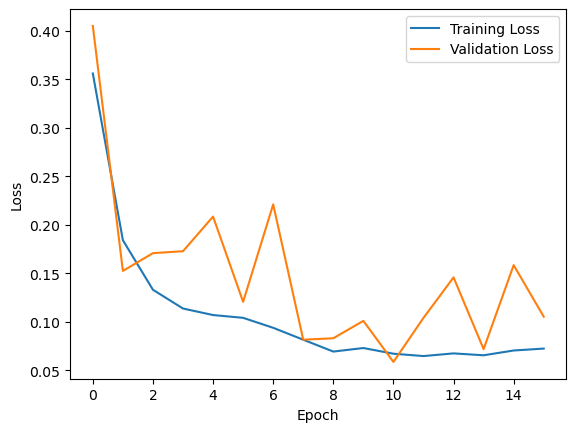

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 1000, 3)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_14 (Conv1D)              │ (None, 1000, 128)      │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 1000, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 1000, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_15 (Conv1D)              │ (None, 1000, 64)       │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 1000, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 1000, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 64000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │     2,048,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,248,325 (23.84 MB)

 Trainable params: 2,082,625 (7.94 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 4,165,252 (15.89 MB)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       576
           1       0.89      0.43      0.58        72

    accuracy                           0.93       648
   macro avg       0.91      0.71      0.77       648
weighted avg       0.93      0.93      0.92       648



In [14]:
#TESTING INTERMITTENT FAULT NO PROCESSING
import os
import numpy as np
import pandas as pd
from scipy.fft import fft
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, Dropout, Dense, Flatten, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

def process_file(file_path, data_segments, labels, label, segment_length=1000):
    """
    Process a single file: split into segments, apply FFT, and assign labels.
    """
    try:
        # Load the CSV file
        df = pd.read_csv(file_path, header=None)
        current_data = df.iloc[:, -3:].values  # Take the last 3 columns (R, Y, B currents)

        # Split into 1-second segments (1000 samples per segment)
        segments = [current_data[i:i + segment_length] for i in range(0, len(current_data), segment_length) if i + segment_length <= len(current_data)]

        # Perform FFT on each segment and keep the shape as (segment_length, 3)
        for segment in segments:
            fft_result = np.abs(fft(segment, axis=0))  # Apply FFT to each phase (R, Y, B)
            data_segments.append(fft_result)  # Shape: (segment_length, 3)
            labels.append(label)

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
    
    return data_segments, labels

def load_intermittent_fault_data(base_dir, segment_length=1000):
    """
    Load intermittent fault data from the specified directory and extract windows.
    """
    intermittent_data = []
    intermittent_labels = []

    # Define window extraction logic for each folder
    window_rules = {
        "0.2s": [(1000, 2000)],  # 1s to 2s
        "0.5s": [(1000, 2000)],  # 1s to 2s
        "1s": [(600, 1600), (1600, 2600)],  # 0.6s to 1.6s and 1.6s to 2.6s
        "2s": [(600, 1600), (2400, 3400)],  # 0.6s to 1.6s and 2.4s to 3.4s
    }

    for folder, windows in window_rules.items():
        folder_path = os.path.join(base_dir, folder)
        if not os.path.exists(folder_path):
            print(f"Folder {folder_path} does not exist. Skipping.")
            continue

        for file in os.listdir(folder_path):
            if file.endswith(".csv"):
                file_path = os.path.join(folder_path, file)
                try:
                    # Load the CSV file
                    df = pd.read_csv(file_path, header=None)
                    current_data = df.iloc[:, -3:].values  # Take the last 3 columns (R, Y, B currents)

                    # Extract the specified windows
                    for start, end in windows:
                        segment = current_data[start:end]
                        if len(segment) == segment_length:
                            fft_result = np.abs(fft(segment, axis=0))  # Apply FFT
                            intermittent_data.append(fft_result)
                            intermittent_labels.append(1)  # Label for fault

                except Exception as e:
                    print(f"Error processing file {file_path}: {e}")

    return np.array(intermittent_data), np.array(intermittent_labels)

def load_and_preprocess_data(data_dir, segment_length=1000, test_size=0.2, random_state=42):
    """
    Load and preprocess data from the directory, splitting fault and no-fault data separately.
    """
    fault_data = []
    no_fault_data = []
    fault_labels = []
    no_fault_labels = []
    file_count = 0  # Initialize file counter

    # Iterate over load levels (e.g., 0.5_A, 1_A, etc.)
    for load in os.listdir(data_dir):
        load_path = os.path.join(data_dir, load)
        if not os.path.isdir(load_path):
            continue

        # Check for Fault and No_Fault directories
        for condition in ["Fault", "No_Fault"]:
            condition_path = os.path.join(load_path, condition)
            if condition == "Fault":  # Handle fault conditions
                for phase in ["P3"]:  # Only process P1 for this NN
                    phase_path = os.path.join(condition_path, phase)
                    if os.path.exists(phase_path):
                        for file in os.listdir(phase_path):
                            if file.endswith(".csv"):
                                file_count += 1  # Increment the file counter
                                file_path = os.path.join(phase_path, file)
                                fault_data, fault_labels = process_file(file_path, fault_data, fault_labels, label=1, segment_length=segment_length)
            elif condition == "No_Fault":  # Handle no fault conditions
                if os.path.exists(condition_path):
                    for file in os.listdir(condition_path):
                        if file.endswith(".csv"):
                            file_count += 1  # Increment the file counter
                            file_path = os.path.join(condition_path, file)
                            no_fault_data, no_fault_labels = process_file(file_path, no_fault_data, no_fault_labels, label=0, segment_length=segment_length)

    print(f"Total files processed: {file_count}")  # Print the total file count
    print(f"Total FFT segments for Fault: {len(fault_data)}")
    print(f"Total FFT segments for No Fault: {len(no_fault_data)}")

    # Convert to numpy arrays
    fault_data = np.array(fault_data)
    no_fault_data = np.array(no_fault_data)
    fault_labels = np.array(fault_labels)
    no_fault_labels = np.array(no_fault_labels)

    # Split fault data into train and test sets
    X_fault_train, _, y_fault_train, _ = train_test_split(
        fault_data, fault_labels, test_size=test_size, random_state=random_state
    )

    # Split no-fault data into train and test sets
    X_no_fault_train, X_no_fault_test, y_no_fault_train, y_no_fault_test = train_test_split(
        no_fault_data, no_fault_labels, test_size=test_size, random_state=random_state
    )

    # Load intermittent fault data for testing
    intermittent_fault_dir = "/home/ani/Project/Interfault/B/"
    X_intermittent_fault, y_intermittent_fault = load_intermittent_fault_data(intermittent_fault_dir, segment_length=segment_length)

    # Combine fault and no-fault data for training
    X_train = np.concatenate((X_fault_train, X_no_fault_train), axis=0)
    y_train = np.concatenate((y_fault_train, y_no_fault_train), axis=0)

    # Use intermittent fault data and no-fault test data for testing
    X_test = np.concatenate((X_intermittent_fault, X_no_fault_test), axis=0)
    y_test = np.concatenate((y_intermittent_fault, y_no_fault_test), axis=0)

    # Shuffle the training and testing data
    train_indices = np.arange(len(X_train))
    test_indices = np.arange(len(X_test))
    np.random.shuffle(train_indices)
    np.random.shuffle(test_indices)

    X_train = X_train[train_indices]
    y_train = y_train[train_indices]
    X_test = X_test[test_indices]
    y_test = y_test[test_indices]

    return X_train, X_test, y_train, y_test

# Directory path to data
base_dir = "/home/ani/DataNN/5kVA/Load"

# Load and preprocess data with 1-second intervals (1000 samples per segment)
segment_length = 1000  # Change to 500 if you want 500 samples per segment
X_train, X_test, y_train, y_test = load_and_preprocess_data(base_dir, segment_length=segment_length)

# Check if data was loaded
if X_train.size == 0 or X_test.size == 0:
    print("No data found! Check the directory structure and file paths.")
    exit()

# Print training and testing FFT segment counts
print(f"Training FFT segments: {len(X_train)}")
print(f"Testing FFT segments: {len(X_test)}")

# Check class distribution
print(f"Class 0 (Healthy) samples in training: {np.sum(y_train == 0)}")
print(f"Class 1 (Faulty) samples in training: {np.sum(y_train == 1)}")
print(f"Class 0 (Healthy) samples in testing: {np.sum(y_test == 0)}")
print(f"Class 1 (Faulty) samples in testing: {np.sum(y_test == 1)}")

# Define the CNN model with a bottleneck layer
def build_cnn_model(input_shape):
    inputs = Input(shape=input_shape)

    # Convolutional layers
    x = Conv1D(128, kernel_size=3, padding='same', activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting

    x = Conv1D(64, kernel_size=4, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting

    x = Flatten()(x)

    # Bottleneck layer
    x = Dense(32)(x)  # Bottleneck size = 32
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting
    x = Activation('relu')(x)

    # Output layer
    outputs = Dense(1, activation='sigmoid')(x)  # Binary classification

    # Create the model
    model = Model(inputs=inputs, outputs=outputs)
    return model

# Build the model
input_shape = (segment_length, 3)  # Input shape: (segment_length, 3)
cnn_model = build_cnn_model(input_shape)

# Compile the model
cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Add early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Add class weighting to address imbalance
class_weights = {0: 1.2, 1: 0.8}  # Adjust weights based on class imbalance

# Train the model with early stopping and class weighting
history = cnn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    class_weight=class_weights
)

# Evaluate the model
loss, accuracy = cnn_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
cnn_model.summary()
# Additional evaluation
y_pred = (cnn_model.predict(X_test) > 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Plotting STFT for 0.2s...


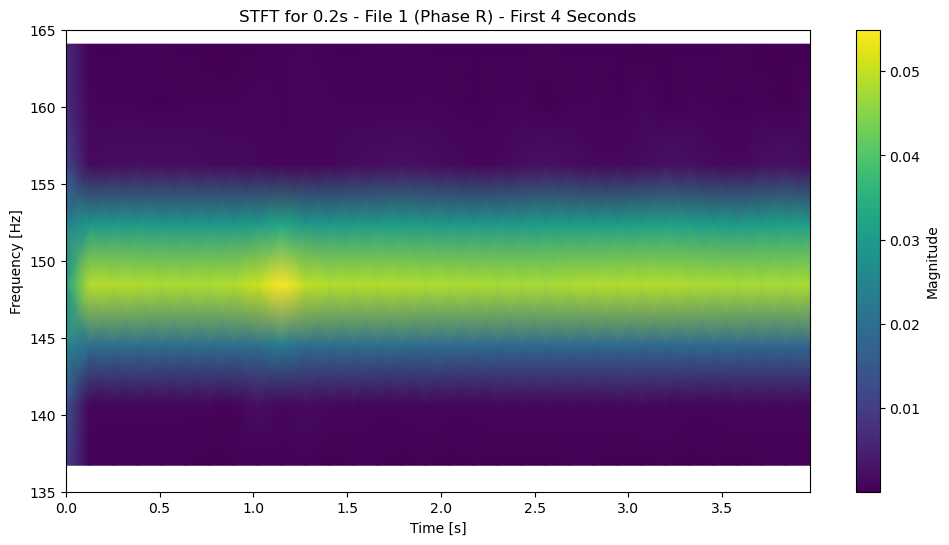

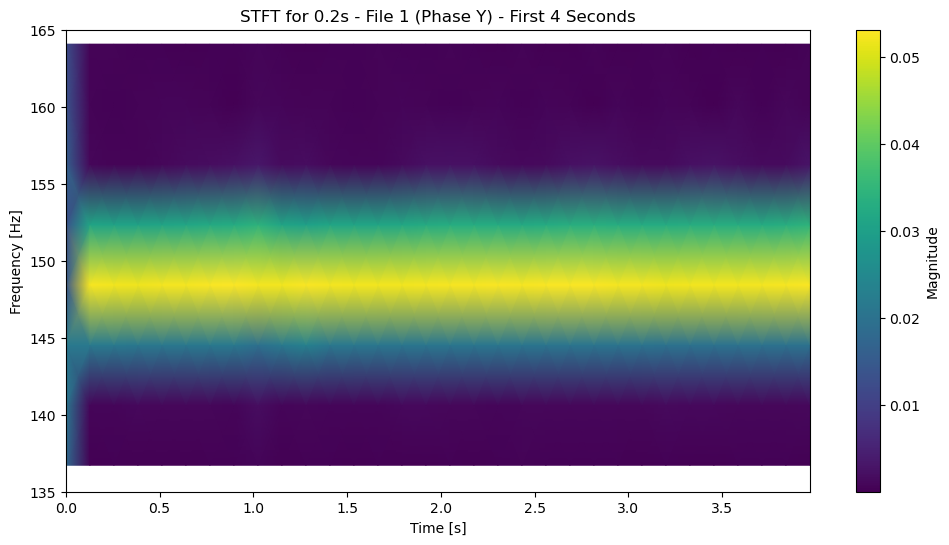

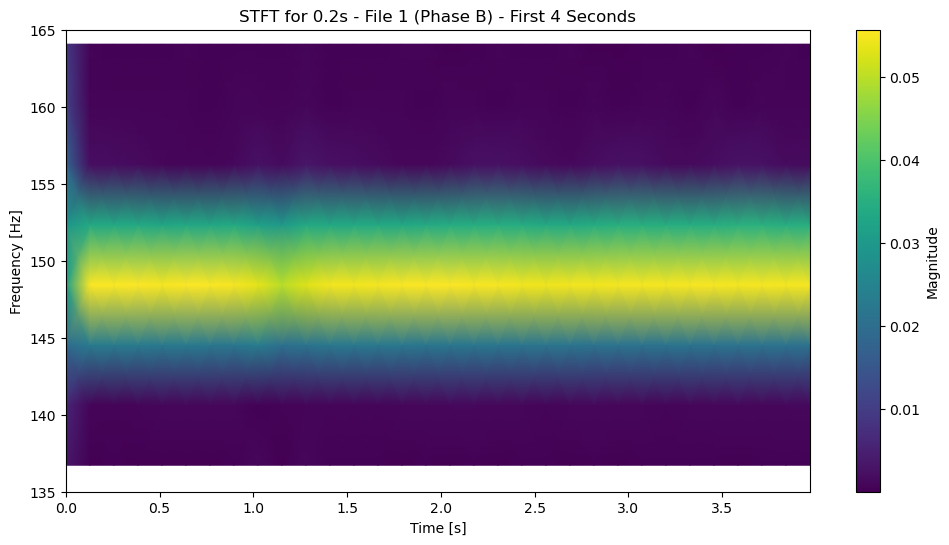

Plotting STFT for 0.5s...


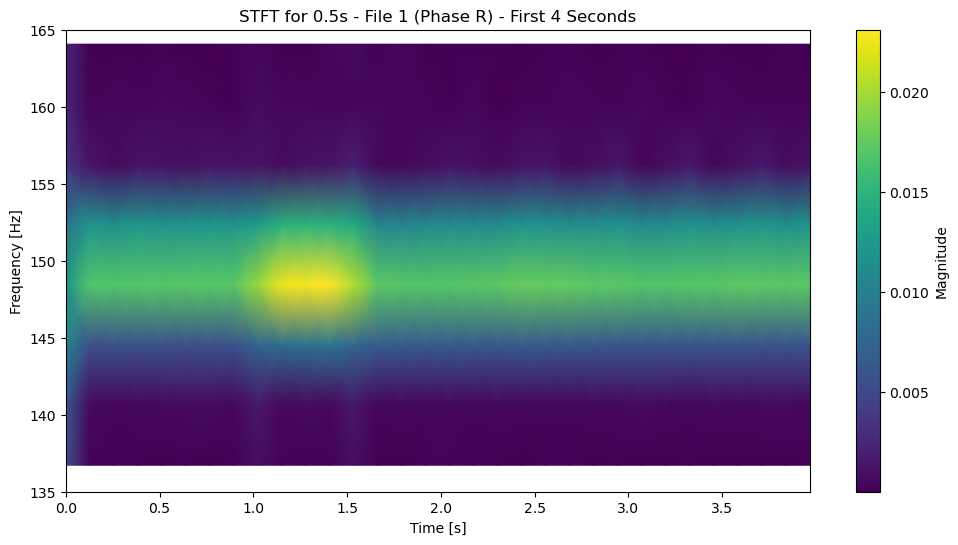

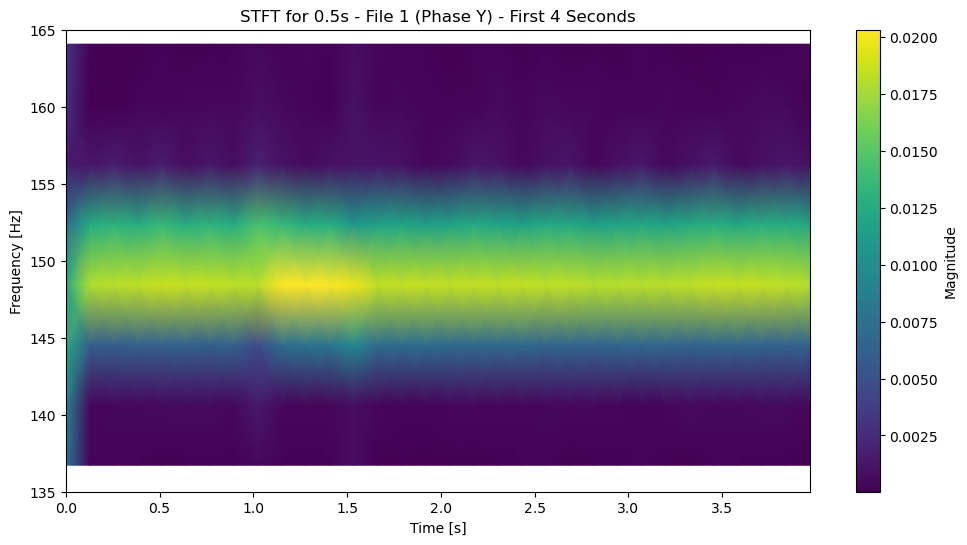

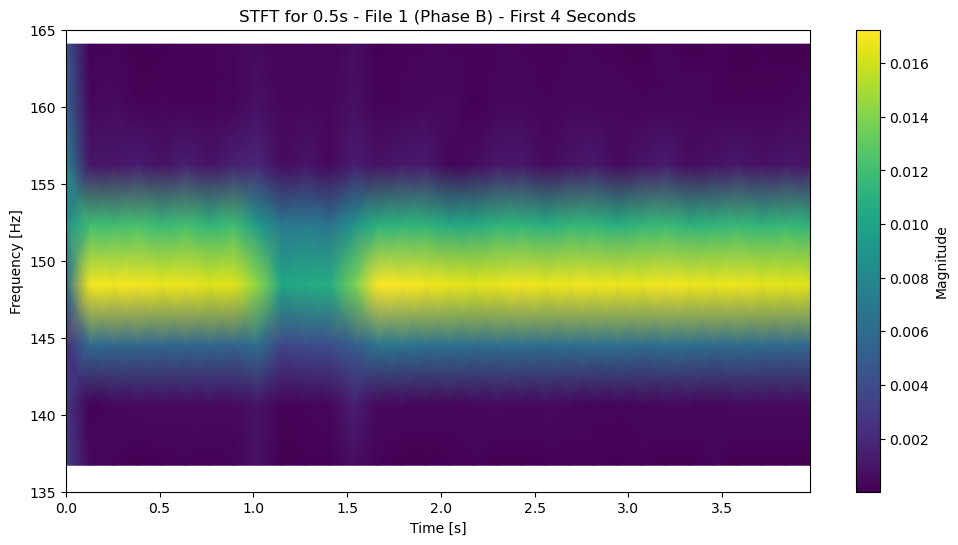

Plotting STFT for 1s...


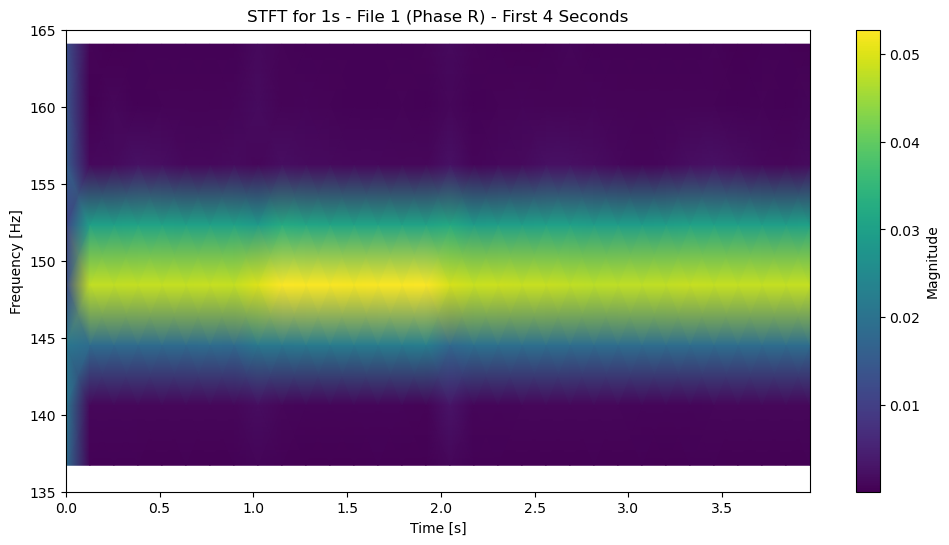

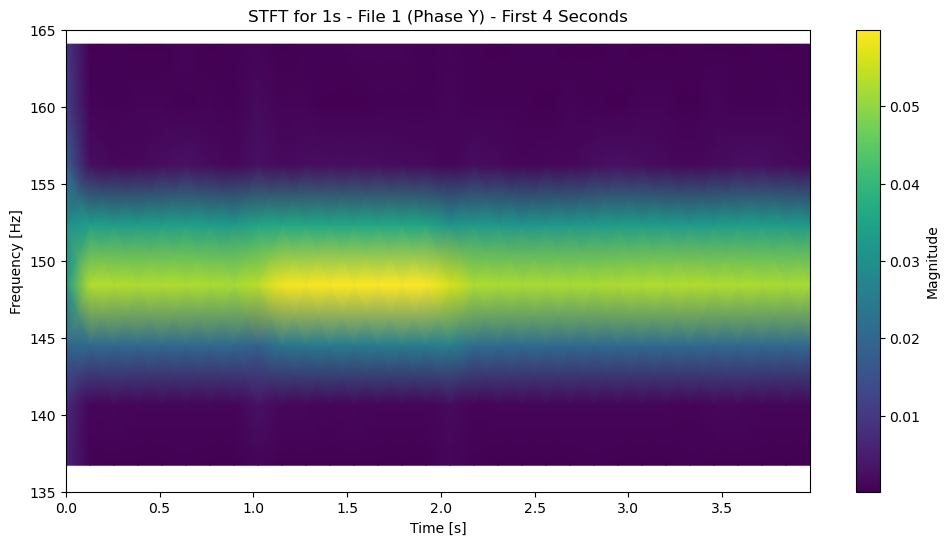

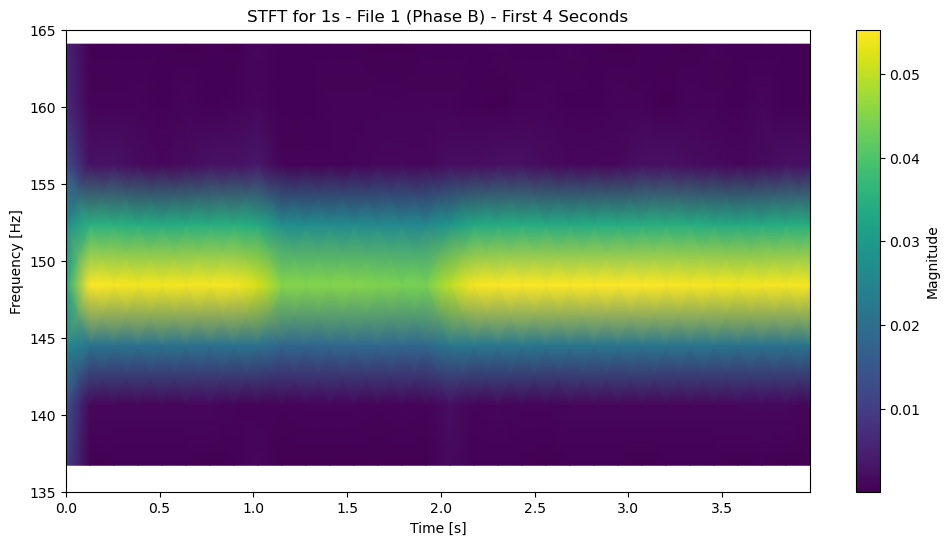

Plotting STFT for 2s...


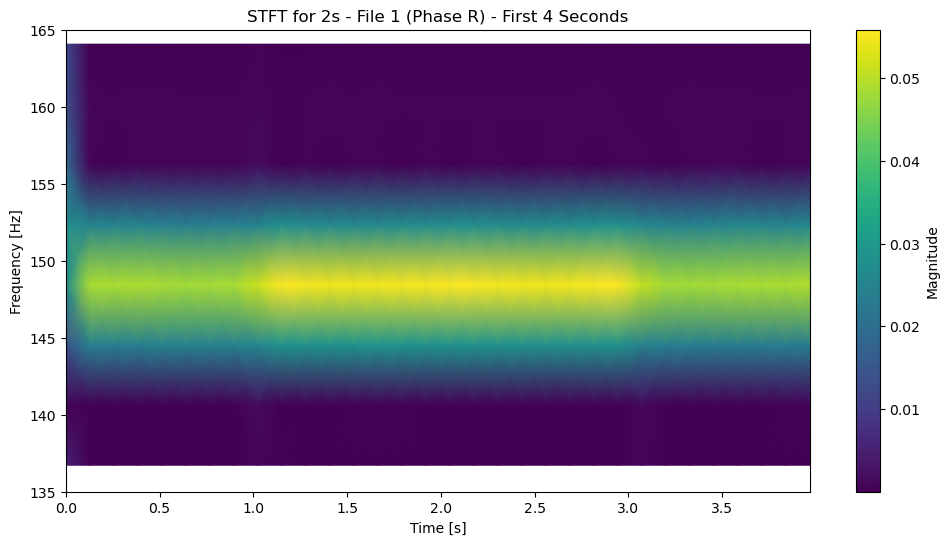

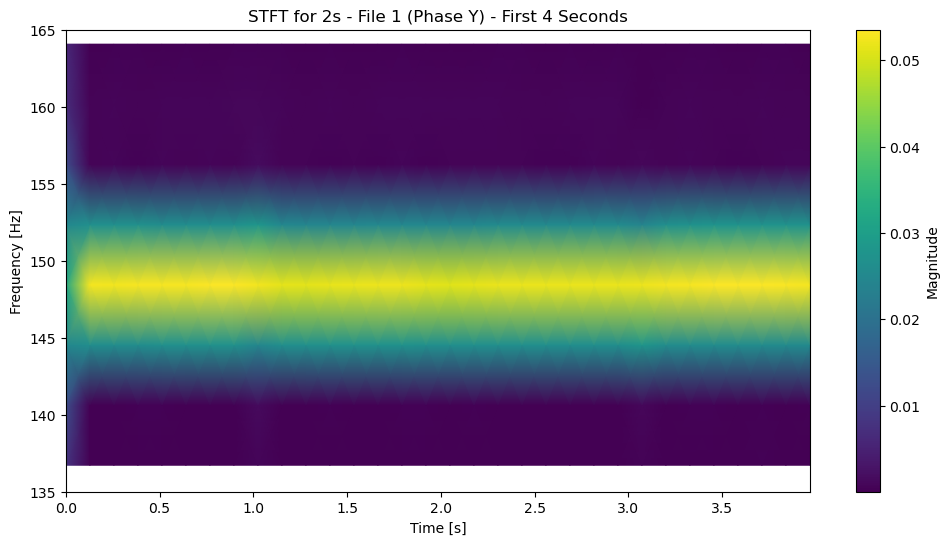

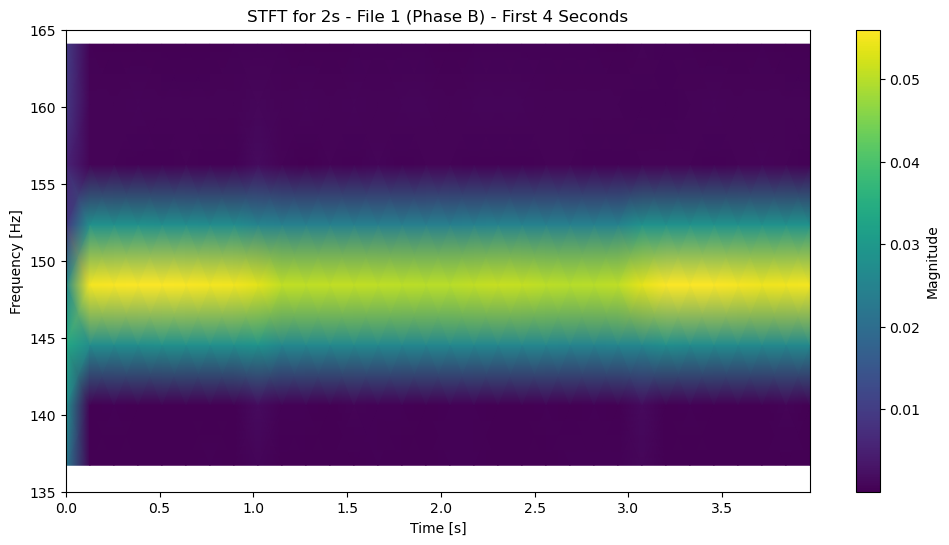

In [15]:
#PLOT FOR STFT
import os
import numpy as np
import pandas as pd
from scipy.signal import stft
import matplotlib.pyplot as plt

def load_intermittent_fault_data(base_dir):
    """
    Load intermittent fault data from the specified directory.
    """
    intermittent_data = {}
    folders = ["0.2s", "0.5s", "1s", "2s"]

    for folder in folders:
        folder_path = os.path.join(base_dir, folder)
        if not os.path.exists(folder_path):
            print(f"Folder {folder_path} does not exist. Skipping.")
            continue

        for file in os.listdir(folder_path):
            if file.endswith(".csv"):
                file_path = os.path.join(folder_path, file)
                try:
                    # Load the CSV file
                    df = pd.read_csv(file_path, header=None)
                    current_data = df.iloc[:, -3:].values  # Take the last 3 columns (R, Y, B currents)

                    if folder not in intermittent_data:
                        intermittent_data[folder] = []
                    intermittent_data[folder].append(current_data)

                except Exception as e:
                    print(f"Error processing file {file_path}: {e}")

    return intermittent_data

def plot_stft(data, folder_name, file_name):
    """
    Compute and plot the STFT of the entire signal, zoomed in to the first 4 seconds and y-axis limited to 135–165 Hz.
    """
    # Compute STFT for each phase
    fs = 1000  # Sampling frequency (1 kHz)
    f, t, Zxx_R = stft(data[:, 0], fs=fs, nperseg=256, noverlap=128)
    _, _, Zxx_Y = stft(data[:, 1], fs=fs, nperseg=256, noverlap=128)
    _, _, Zxx_B = stft(data[:, 2], fs=fs, nperseg=256, noverlap=128)

    # Zoom in to the first 4 seconds
    zoom_time = 4  # Time limit in seconds
    zoom_index = np.where(t <= zoom_time)[0]  # Find indices for the first 4 seconds

    # Limit y-axis to 135–165 Hz
    freq_lower = 135  # Lower frequency limit in Hz
    freq_upper = 165  # Upper frequency limit in Hz
    freq_index = np.where((f >= freq_lower) & (f <= freq_upper))[0]  # Find indices for frequencies in 135–165 Hz

    # Plot STFT for Phase R
    plt.figure(figsize=(12, 6))
    plt.pcolormesh(t[zoom_index], f[freq_index], np.abs(Zxx_R[freq_index][:, zoom_index]), shading='gouraud')
    plt.title(f"STFT for {folder_name} - {file_name} (Phase R) - First 4 Seconds")
    plt.xlabel("Time [s]")
    plt.ylabel("Frequency [Hz]")
    plt.ylim(freq_lower, freq_upper)  # Set y-axis limit
    plt.colorbar(label="Magnitude")
    plt.show()

    # Plot STFT for Phase Y
    plt.figure(figsize=(12, 6))
    plt.pcolormesh(t[zoom_index], f[freq_index], np.abs(Zxx_Y[freq_index][:, zoom_index]), shading='gouraud')
    plt.title(f"STFT for {folder_name} - {file_name} (Phase Y) - First 4 Seconds")
    plt.xlabel("Time [s]")
    plt.ylabel("Frequency [Hz]")
    plt.ylim(freq_lower, freq_upper)  # Set y-axis limit
    plt.colorbar(label="Magnitude")
    plt.show()

    # Plot STFT for Phase B
    plt.figure(figsize=(12, 6))
    plt.pcolormesh(t[zoom_index], f[freq_index], np.abs(Zxx_B[freq_index][:, zoom_index]), shading='gouraud')
    plt.title(f"STFT for {folder_name} - {file_name} (Phase B) - First 4 Seconds")
    plt.xlabel("Time [s]")
    plt.ylabel("Frequency [Hz]")
    plt.ylim(freq_lower, freq_upper)  # Set y-axis limit
    plt.colorbar(label="Magnitude")
    plt.show()

# Directory path to intermittent fault data
intermittent_fault_dir = "/home/ani/Project/Interfault/B/"

# Load intermittent fault data
intermittent_data = load_intermittent_fault_data(intermittent_fault_dir)

# Check if data was loaded
if not intermittent_data:
    print("No intermittent fault data found! Check the directory structure and file paths.")
    exit()

# Plot STFT for 1 file per folder
for folder, data_list in intermittent_data.items():
    if data_list:  # Check if data exists for the folder
        print(f"Plotting STFT for {folder}...")
        file_name = "File 1"  # Only plot the first file
        plot_stft(data_list[0], folder, file_name)  # Use the first file in the folder

Total files processed: 720
Total FFT segments for Fault: 4320
Total FFT segments for No Fault: 2880
Training FFT segments: 5760
Testing FFT segments: 648
Class 0 (Healthy) samples in training: 2304
Class 1 (Faulty) samples in training: 3456
Class 0 (Healthy) samples in testing: 576
Class 1 (Faulty) samples in testing: 72
Epoch 1/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7212 - loss: 0.5117 - val_accuracy: 0.9392 - val_loss: 0.3082
Epoch 2/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9273 - loss: 0.1948 - val_accuracy: 0.8594 - val_loss: 0.2956
Epoch 3/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9462 - loss: 0.1532 - val_accuracy: 0.9262 - val_loss: 0.1959
Epoch 4/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9547 - loss: 0.1366 - val_accuracy: 0.9271 - val_loss: 0.1756
Epoch 5/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9620 - loss: 0.1146 - val_accuracy: 0.9844 - val_loss: 0.0708
Epoch 6/50
144/144 ━━━━━━━━━━━━━━━━━━

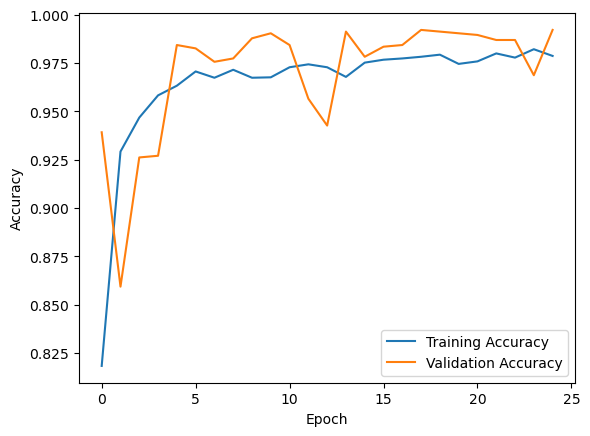

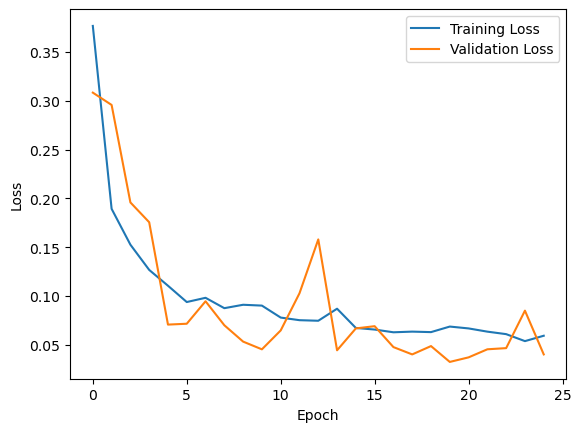

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 1000, 3)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_16 (Conv1D)              │ (None, 1000, 128)      │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 1000, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 1000, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_17 (Conv1D)              │ (None, 1000, 64)       │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 1000, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 1000, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 64000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │     2,048,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,248,325 (23.84 MB)

 Trainable params: 2,082,625 (7.94 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 4,165,252 (15.89 MB)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       576
           1       0.93      0.99      0.96        72

    accuracy                           0.99       648
   macro avg       0.97      0.99      0.98       648
weighted avg       0.99      0.99      0.99       648



In [16]:
#TESTING INTERMITTENT FAULT WAVELET DB4
import os
import numpy as np
import pandas as pd
from scipy.fft import fft
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, Dropout, Dense, Flatten, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

def process_file(file_path, data_segments, labels, label, segment_length=1000):
    """
    Process a single file: split into segments, apply FFT, and assign labels.
    """
    try:
        # Load the CSV file
        df = pd.read_csv(file_path, header=None)
        current_data = df.iloc[:, -3:].values  # Take the last 3 columns (R, Y, B currents)

        # Split into 1-second segments (1000 samples per segment)
        segments = [current_data[i:i + segment_length] for i in range(0, len(current_data), segment_length) if i + segment_length <= len(current_data)]

        # Perform FFT on each segment and keep the shape as (segment_length, 3)
        for segment in segments:
            fft_result = np.abs(fft(segment, axis=0))  # Apply FFT to each phase (R, Y, B)
            data_segments.append(fft_result)  # Shape: (segment_length, 3)
            labels.append(label)

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
    
    return data_segments, labels

def load_intermittent_fault_data(base_dir, segment_length=1000):
    """
    Load intermittent fault data from the specified directory and extract windows.
    """
    intermittent_data = []
    intermittent_labels = []

    # Define window extraction logic for each folder
    window_rules = {
        "0.2s": [(1000, 2000)],  # 1s to 2s
        "0.5s": [(1000, 2000)],  # 1s to 2s
        "1s": [(600, 1600), (1600, 2600)],  # 0.6s to 1.6s and 1.6s to 2.6s
        "2s": [(600, 1600), (2400, 3400)],  # 0.6s to 1.6s and 2.4s to 3.4s
    }

    for folder, windows in window_rules.items():
        folder_path = os.path.join(base_dir, folder)
        if not os.path.exists(folder_path):
            print(f"Folder {folder_path} does not exist. Skipping.")
            continue

        for file in os.listdir(folder_path):
            if file.endswith(".csv"):
                file_path = os.path.join(folder_path, file)
                try:
                    # Load the CSV file
                    df = pd.read_csv(file_path, header=None)
                    current_data = df.iloc[:, -3:].values  # Take the last 3 columns (R, Y, B currents)

                    # Extract the specified windows
                    for start, end in windows:
                        segment = current_data[start:end]
                        if len(segment) == segment_length:
                            fft_result = np.abs(fft(segment, axis=0))  # Apply FFT
                            intermittent_data.append(fft_result)
                            intermittent_labels.append(1)  # Label for fault

                except Exception as e:
                    print(f"Error processing file {file_path}: {e}")

    return np.array(intermittent_data), np.array(intermittent_labels)

def load_and_preprocess_data(data_dir, segment_length=1000, test_size=0.2, random_state=42):
    """
    Load and preprocess data from the directory, splitting fault and no-fault data separately.
    """
    fault_data = []
    no_fault_data = []
    fault_labels = []
    no_fault_labels = []
    file_count = 0  # Initialize file counter

    # Iterate over load levels (e.g., 0.5_A, 1_A, etc.)
    for load in os.listdir(data_dir):
        load_path = os.path.join(data_dir, load)
        if not os.path.isdir(load_path):
            continue

        # Check for Fault and No_Fault directories
        for condition in ["Fault", "No_Fault"]:
            condition_path = os.path.join(load_path, condition)
            if condition == "Fault":  # Handle fault conditions
                for phase in ["P3"]:  # Only process P1 for this NN
                    phase_path = os.path.join(condition_path, phase)
                    if os.path.exists(phase_path):
                        for file in os.listdir(phase_path):
                            if file.endswith(".csv"):
                                file_count += 1  # Increment the file counter
                                file_path = os.path.join(phase_path, file)
                                fault_data, fault_labels = process_file(file_path, fault_data, fault_labels, label=1, segment_length=segment_length)
            elif condition == "No_Fault":  # Handle no fault conditions
                if os.path.exists(condition_path):
                    for file in os.listdir(condition_path):
                        if file.endswith(".csv"):
                            file_count += 1  # Increment the file counter
                            file_path = os.path.join(condition_path, file)
                            no_fault_data, no_fault_labels = process_file(file_path, no_fault_data, no_fault_labels, label=0, segment_length=segment_length)

    print(f"Total files processed: {file_count}")  # Print the total file count
    print(f"Total FFT segments for Fault: {len(fault_data)}")
    print(f"Total FFT segments for No Fault: {len(no_fault_data)}")

    # Convert to numpy arrays
    fault_data = np.array(fault_data)
    no_fault_data = np.array(no_fault_data)
    fault_labels = np.array(fault_labels)
    no_fault_labels = np.array(no_fault_labels)

    # Split fault data into train and test sets
    X_fault_train, _, y_fault_train, _ = train_test_split(
        fault_data, fault_labels, test_size=test_size, random_state=random_state
    )

    # Split no-fault data into train and test sets
    X_no_fault_train, X_no_fault_test, y_no_fault_train, y_no_fault_test = train_test_split(
        no_fault_data, no_fault_labels, test_size=test_size, random_state=random_state
    )

    # Load intermittent fault data for testing
    intermittent_fault_dir = "/home/ani/Project/Interfault_db4/B/"
    X_intermittent_fault, y_intermittent_fault = load_intermittent_fault_data(intermittent_fault_dir, segment_length=segment_length)

    # Combine fault and no-fault data for training
    X_train = np.concatenate((X_fault_train, X_no_fault_train), axis=0)
    y_train = np.concatenate((y_fault_train, y_no_fault_train), axis=0)

    # Use intermittent fault data and no-fault test data for testing
    X_test = np.concatenate((X_intermittent_fault, X_no_fault_test), axis=0)
    y_test = np.concatenate((y_intermittent_fault, y_no_fault_test), axis=0)

    # Shuffle the training and testing data
    train_indices = np.arange(len(X_train))
    test_indices = np.arange(len(X_test))
    np.random.shuffle(train_indices)
    np.random.shuffle(test_indices)

    X_train = X_train[train_indices]
    y_train = y_train[train_indices]
    X_test = X_test[test_indices]
    y_test = y_test[test_indices]

    return X_train, X_test, y_train, y_test

# Directory path to data
base_dir = "/home/ani/DataNN/5kVA/Load"

# Load and preprocess data with 1-second intervals (1000 samples per segment)
segment_length = 1000  # Change to 500 if you want 500 samples per segment
X_train, X_test, y_train, y_test = load_and_preprocess_data(base_dir, segment_length=segment_length)

# Check if data was loaded
if X_train.size == 0 or X_test.size == 0:
    print("No data found! Check the directory structure and file paths.")
    exit()

# Print training and testing FFT segment counts
print(f"Training FFT segments: {len(X_train)}")
print(f"Testing FFT segments: {len(X_test)}")

# Check class distribution
print(f"Class 0 (Healthy) samples in training: {np.sum(y_train == 0)}")
print(f"Class 1 (Faulty) samples in training: {np.sum(y_train == 1)}")
print(f"Class 0 (Healthy) samples in testing: {np.sum(y_test == 0)}")
print(f"Class 1 (Faulty) samples in testing: {np.sum(y_test == 1)}")

# Define the CNN model with a bottleneck layer
def build_cnn_model(input_shape):
    inputs = Input(shape=input_shape)

    # Convolutional layers
    x = Conv1D(128, kernel_size=3, padding='same', activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting

    x = Conv1D(64, kernel_size=4, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting

    x = Flatten()(x)

    # Bottleneck layer
    x = Dense(32)(x)  # Bottleneck size = 32
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting
    x = Activation('relu')(x)

    # Output layer
    outputs = Dense(1, activation='sigmoid')(x)  # Binary classification

    # Create the model
    model = Model(inputs=inputs, outputs=outputs)
    return model

# Build the model
input_shape = (segment_length, 3)  # Input shape: (segment_length, 3)
cnn_model = build_cnn_model(input_shape)

# Compile the model
cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Add early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Add class weighting to address imbalance
class_weights = {0: 1.2, 1: 0.8}  # Adjust weights based on class imbalance

# Train the model with early stopping and class weighting
history = cnn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    class_weight=class_weights
)

# Evaluate the model
loss, accuracy = cnn_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
cnn_model.summary()
# Additional evaluation
y_pred = (cnn_model.predict(X_test) > 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

In [17]:
#CNN Time Domain Data
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, Dropout, Dense, Flatten, Activation
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report
from tensorflow.keras.models import Model

def process_file(file_path, data_segments, labels, label, segment_count, segment_length=1000):
    """
    Process a single file: split into segments and assign labels.
    """
    try:
        # Load the CSV file
        df = pd.read_csv(file_path, header=None)
        current_data = df.iloc[:, -3:].values  # Take the last 3 columns (R, Y, B currents)

        # Split into 1-second segments (1000 samples per segment)
        segments = [current_data[i:i + segment_length] for i in range(0, len(current_data), segment_length) if i + segment_length <= len(current_data)]

        # Append raw time-domain segments directly (no FFT)
        for segment in segments:
            data_segments.append(segment)  # Shape: (segment_length, 3)
            labels.append(label)
            segment_count[label] += 1  # Increment the count for the respective label

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
    
    return data_segments, labels, segment_count

def load_and_preprocess_data(data_dir, segment_length=1000):
    """
    Load and preprocess data from the directory.
    """
    data_segments = []
    labels = []
    segment_count = {0: 0, 1: 0}  # Count of segments for No_Fault (0) and Fault (1)
    file_count = 0  # Initialize file counter

    # Iterate over load levels (e.g., 0.5_A, 1_A, etc.)
    for load in os.listdir(data_dir):
        load_path = os.path.join(data_dir, load)
        if not os.path.isdir(load_path):
            continue

        # Check for Fault and No_Fault directories
        for condition in ["Fault", "No_Fault"]:
            condition_path = os.path.join(load_path, condition)
            if condition == "Fault":  # Handle fault conditions
                for phase in ["P3"]:  # Only process P1 for this NN
                    phase_path = os.path.join(condition_path, phase)
                    if os.path.exists(phase_path):
                        for file in os.listdir(phase_path):
                            if file.endswith(".csv"):
                                file_count += 1  # Increment the file counter
                                file_path = os.path.join(phase_path, file)
                                data_segments, labels, segment_count = process_file(file_path, data_segments, labels, label=1, segment_count=segment_count, segment_length=segment_length)
            elif condition == "No_Fault":  # Handle no fault conditions
                if os.path.exists(condition_path):
                    for file in os.listdir(condition_path):
                        if file.endswith(".csv"):
                            file_count += 1  # Increment the file counter
                            file_path = os.path.join(condition_path, file)
                            data_segments, labels, segment_count = process_file(file_path, data_segments, labels, label=0, segment_count=segment_count, segment_length=segment_length)

    print(f"Total files processed: {file_count}")  # Print the total file count
    print(f"Total segments for Fault: {segment_count[1]}")
    print(f"Total segments for No Fault: {segment_count[0]}")
    return np.array(data_segments), np.array(labels)

# Directory path to data
base_dir = "/home/ani/DataNN/5kVA/Load"

# Load and preprocess data with 1-second intervals (1000 samples per segment)
segment_length = 1000  # Change to 500 if you want 500 samples per segment
data, labels = load_and_preprocess_data(base_dir, segment_length=segment_length)

# Check if data was loaded
if data.size == 0:
    print("No data found! Check the directory structure and file paths.")
    exit()

# Normalize data
data = (data - np.min(data)) / (np.max(data) - np.min(data))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

# Print training and testing segment counts
print(f"Training segments: {len(X_train)}")
print(f"Testing segments: {len(X_test)}")

# Define the CNN model with a bottleneck layer
def build_cnn_model(input_shape):
    inputs = Input(shape=input_shape)

    # Only one convolutional layer
    x = Conv1D(32, kernel_size=3, padding='same', activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)

    x = Flatten()(x)

    # Smaller bottleneck layer
    x = Dense(16)(x)  # Reduced bottleneck size
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    x = Activation('relu')(x)

    # Output layer
    outputs = Dense(1, activation='sigmoid')(x)  # Binary classification

    # Create the model
    model = Model(inputs=inputs, outputs=outputs)
    return model

# Build the simpler model
input_shape = (segment_length, 3)  # Input shape: (segment_length, 3)
cnn_model = build_cnn_model(input_shape)

# Compile the model
cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
cnn_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Build the model
input_shape = (segment_length, 3)  # Input shape: (segment_length, 3)
cnn_model = build_cnn_model(input_shape)

# Compile the model
cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
cnn_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Evaluate the model
loss, accuracy = cnn_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Display model summary
print("\nModel Summary:")
cnn_model.summary()
# Additional evaluation
y_pred = (cnn_model.predict(X_test) > 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Total files processed: 720
Total segments for Fault: 4320
Total segments for No Fault: 2880
Training segments: 5760
Testing segments: 1440
Epoch 1/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5413 - loss: 0.7966 - val_accuracy: 0.5642 - val_loss: 0.6768
Epoch 2/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5806 - loss: 0.6805 - val_accuracy: 0.5868 - val_loss: 0.6516
Epoch 3/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6199 - loss: 0.6283 - val_accuracy: 0.6276 - val_loss: 0.6212
Epoch 4/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6534 - loss: 0.6080 - val_accuracy: 0.7214 - val_loss: 0.5880
Epoch 5/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6760 - loss: 0.5855 - val_accuracy: 0.5911 - val_loss: 0.6286
Epoch 6/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6738 - loss: 0.5750 - val_accuracy: 0.5122 - val_loss: 0.7117
Epoch 7/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6722 - loss: 0.5855 - val_a

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 1000, 3)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_19 (Conv1D)              │ (None, 1000, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 1000, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 1000, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 32000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 16)             │       512,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537,445 (5.86 MB)

 Trainable params: 512,449 (1.95 MB)

 Non-trainable params: 96 (384.00 B)

 Optimizer params: 1,024,900 (3.91 MB)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 953us/step

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       568
           1       0.61      1.00      0.75       872

    accuracy                           0.61      1440
   macro avg       0.30      0.50      0.38      1440
weighted avg       0.37      0.61      0.46      1440



/home/ani/anaconda3/envs/tf/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ani/anaconda3/envs/tf/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ani/anaconda3/envs/tf/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result)

Total files processed: 720
Total STFT segments for Fault: 4320
Total STFT segments for No Fault: 2880
Training STFT segments: 5760
Testing STFT segments: 648
Class 0 (Healthy) samples in training: 2304
Class 1 (Faulty) samples in training: 3456
Class 0 (Healthy) samples in testing: 576
Class 1 (Faulty) samples in testing: 72
Epoch 1/50


2025-02-13 21:48:19.236335: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:306] Allocator (GPU_0_bfc) ran out of memory trying to allocate 6.06GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-02-13 21:48:19.792038: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:306] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.06GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


141/144 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6437 - loss: 0.6066

2025-02-13 21:48:22.381315: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:306] Allocator (GPU_0_bfc) ran out of memory trying to allocate 6.06GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


144/144 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6478 - loss: 0.6010 - val_accuracy: 0.4227 - val_loss: 0.8261
Epoch 2/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9706 - loss: 0.1297 - val_accuracy: 0.5590 - val_loss: 0.6325
Epoch 3/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9795 - loss: 0.0988 - val_accuracy: 0.7535 - val_loss: 0.5264
Epoch 4/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9837 - loss: 0.0714 - val_accuracy: 0.6441 - val_loss: 0.4792
Epoch 5/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9817 - loss: 0.0769 - val_accuracy: 0.9019 - val_loss: 0.2245
Epoch 6/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9791 - loss: 0.0896 - val_accuracy: 0.9905 - val_loss: 0.0621
Epoch 7/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9887 - loss: 0.0520 - val_accuracy: 0.9905 - val_loss: 0.0502
Epoch 8/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9827 - loss: 0.0711 - val_accuracy: 0.9905 - val

2025-02-13 21:48:47.867641: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:306] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.55GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


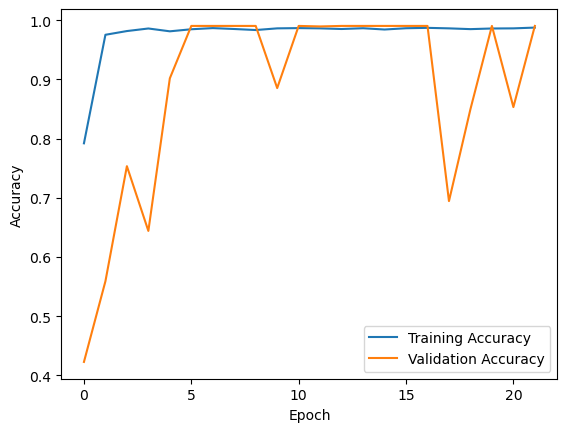

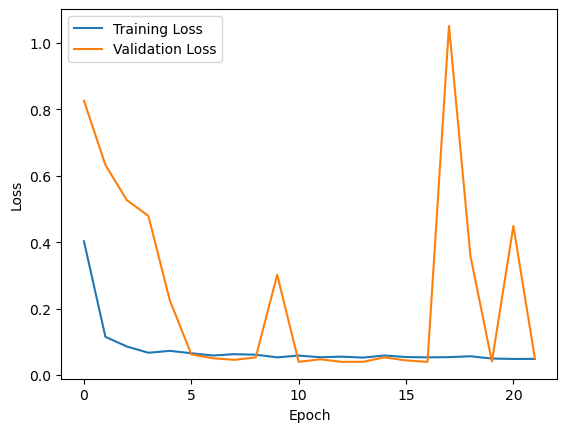

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       576
           1       1.00      0.03      0.05        72

    accuracy                           0.89       648
   macro avg       0.95      0.51      0.50       648
weighted avg       0.90      0.89      0.84       648



In [18]:
import os
import numpy as np
import pandas as pd
from scipy.signal import stft
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Dropout, Dense, Flatten, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

def create_weighting_matrix(frequencies, time_frames, transition_frames, target_freq=150, fs=1000):
    """
    Create a weighting matrix to emphasize transition locations and a target frequency (150 Hz).
    """
    # Initialize weighting matrix with ones
    weighting_matrix = np.ones((len(frequencies), len(time_frames)))

    # Emphasize transition locations
    for frame in transition_frames:
        weighting_matrix[:, frame] *= 2  # Amplify transition frames

    # Emphasize 150 Hz frequency
    freq_idx = np.argmin(np.abs(frequencies - target_freq))  # Find index of 150 Hz
    weighting_matrix[freq_idx, :] *= 3  # Amplify 150 Hz frequency

    return weighting_matrix

def process_file(file_path, data_segments, labels, label, segment_length=1000, fs=1000):
    """
    Process a single file: split into segments, apply STFT, and assign labels.
    """
    try:
        # Load the CSV file
        df = pd.read_csv(file_path, header=None)
        current_data = df.iloc[:, -3:].values  # Take the last 3 columns (R, Y, B currents)

        # Split into 1-second segments (1000 samples per segment)
        segments = [current_data[i:i + segment_length] for i in range(0, len(current_data), segment_length) if i + segment_length <= len(current_data)]

        # Perform STFT on each segment
        for segment in segments:
            stft_results = []
            for phase in range(3):  # Apply STFT to each phase (R, Y, B)
                f, t, Zxx = stft(segment[:, phase], fs=fs, nperseg=256, noverlap=128)
                stft_results.append(np.abs(Zxx))  # Take the magnitude of the STFT

            # Create weighting matrix to emphasize transitions and 150 Hz
            transition_frames = [len(t) // 4, len(t) // 2, 3 * len(t) // 4]  # Example transition frames
            weighting_matrix = create_weighting_matrix(f, t, transition_frames, target_freq=150, fs=fs)

            # Apply weighting to STFT results
            for i in range(3):
                stft_results[i] *= weighting_matrix

            stft_results = np.stack(stft_results, axis=-1)  # Shape: (frequencies, time, 3)
            data_segments.append(stft_results)
            labels.append(label)

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
    
    return data_segments, labels

def load_intermittent_fault_data(base_dir, segment_length=1000, fs=1000):
    """
    Load intermittent fault data from the specified directory and extract windows.
    """
    intermittent_data = []
    intermittent_labels = []

    # Define window extraction logic for each folder
    window_rules = {
        "0.2s": [(1000, 2000)],  # 1s to 2s
        "0.5s": [(1000, 2000)],  # 1s to 2s
        "1s": [(600, 1600), (1600, 2600)],  # 0.6s to 1.6s and 1.6s to 2.6s
        "2s": [(600, 1600), (2400, 3400)],  # 0.6s to 1.6s and 2.4s to 3.4s
    }

    for folder, windows in window_rules.items():
        folder_path = os.path.join(base_dir, folder)
        if not os.path.exists(folder_path):
            print(f"Folder {folder_path} does not exist. Skipping.")
            continue

        for file in os.listdir(folder_path):
            if file.endswith(".csv"):
                file_path = os.path.join(folder_path, file)
                try:
                    # Load the CSV file
                    df = pd.read_csv(file_path, header=None)
                    current_data = df.iloc[:, -3:].values  # Take the last 3 columns (R, Y, B currents)

                    # Extract the specified windows
                    for start, end in windows:
                        segment = current_data[start:end]
                        if len(segment) == segment_length:
                            stft_results = []
                            for phase in range(3):  # Apply STFT to each phase
                                f, t, Zxx = stft(segment[:, phase], fs=fs, nperseg=256, noverlap=128)
                                stft_results.append(np.abs(Zxx))  # Take the magnitude of the STFT

                            # Create weighting matrix to emphasize transitions and 150 Hz
                            transition_frames = [len(t) // 4, len(t) // 2, 3 * len(t) // 4]  # Example transition frames
                            weighting_matrix = create_weighting_matrix(f, t, transition_frames, target_freq=150, fs=fs)

                            # Apply weighting to STFT results
                            for i in range(3):
                                stft_results[i] *= weighting_matrix

                            stft_results = np.stack(stft_results, axis=-1)  # Shape: (frequencies, time, 3)
                            intermittent_data.append(stft_results)
                            intermittent_labels.append(1)  # Label for fault

                except Exception as e:
                    print(f"Error processing file {file_path}: {e}")

    return np.array(intermittent_data), np.array(intermittent_labels)

def load_and_preprocess_data(data_dir, segment_length=1000, test_size=0.2, random_state=42, fs=1000):
    """
    Load and preprocess data from the directory, splitting fault and no-fault data separately.
    """
    fault_data = []
    no_fault_data = []
    fault_labels = []
    no_fault_labels = []
    file_count = 0  # Initialize file counter

    # Iterate over load levels (e.g., 0.5_A, 1_A, etc.)
    for load in os.listdir(data_dir):
        load_path = os.path.join(data_dir, load)
        if not os.path.isdir(load_path):
            continue

        # Check for Fault and No_Fault directories
        for condition in ["Fault", "No_Fault"]:
            condition_path = os.path.join(load_path, condition)
            if condition == "Fault":  # Handle fault conditions
                for phase in ["P3"]:  # Only process P1 for this NN
                    phase_path = os.path.join(condition_path, phase)
                    if os.path.exists(phase_path):
                        for file in os.listdir(phase_path):
                            if file.endswith(".csv"):
                                file_count += 1  # Increment the file counter
                                file_path = os.path.join(phase_path, file)
                                fault_data, fault_labels = process_file(file_path, fault_data, fault_labels, label=1, segment_length=segment_length, fs=fs)
            elif condition == "No_Fault":  # Handle no fault conditions
                if os.path.exists(condition_path):
                    for file in os.listdir(condition_path):
                        if file.endswith(".csv"):
                            file_count += 1  # Increment the file counter
                            file_path = os.path.join(condition_path, file)
                            no_fault_data, no_fault_labels = process_file(file_path, no_fault_data, no_fault_labels, label=0, segment_length=segment_length, fs=fs)

    print(f"Total files processed: {file_count}")  # Print the total file count
    print(f"Total STFT segments for Fault: {len(fault_data)}")
    print(f"Total STFT segments for No Fault: {len(no_fault_data)}")

    # Convert to numpy arrays
    fault_data = np.array(fault_data)
    no_fault_data = np.array(no_fault_data)
    fault_labels = np.array(fault_labels)
    no_fault_labels = np.array(no_fault_labels)

    # Split fault data into train and test sets
    X_fault_train, _, y_fault_train, _ = train_test_split(
        fault_data, fault_labels, test_size=test_size, random_state=random_state
    )

    # Split no-fault data into train and test sets
    X_no_fault_train, X_no_fault_test, y_no_fault_train, y_no_fault_test = train_test_split(
        no_fault_data, no_fault_labels, test_size=test_size, random_state=random_state
    )

    # Load intermittent fault data for testing
    intermittent_fault_dir = "/home/ani/Project/Interfault/B/"
    X_intermittent_fault, y_intermittent_fault = load_intermittent_fault_data(intermittent_fault_dir, segment_length=segment_length, fs=fs)

    # Combine fault and no-fault data for training
    X_train = np.concatenate((X_fault_train, X_no_fault_train), axis=0)
    y_train = np.concatenate((y_fault_train, y_no_fault_train), axis=0)

    # Use intermittent fault data and no-fault test data for testing
    X_test = np.concatenate((X_intermittent_fault, X_no_fault_test), axis=0)
    y_test = np.concatenate((y_intermittent_fault, y_no_fault_test), axis=0)

    # Shuffle the training and testing data
    train_indices = np.arange(len(X_train))
    test_indices = np.arange(len(X_test))
    np.random.shuffle(train_indices)
    np.random.shuffle(test_indices)

    X_train = X_train[train_indices]
    y_train = y_train[train_indices]
    X_test = X_test[test_indices]
    y_test = y_test[test_indices]

    return X_train, X_test, y_train, y_test

# Directory path to data
base_dir = "/home/ani/DataNN/5kVA/Load"

# Load and preprocess data with 1-second intervals (1000 samples per segment)
segment_length = 1000  # Change to 500 if you want 500 samples per segment
X_train, X_test, y_train, y_test = load_and_preprocess_data(base_dir, segment_length=segment_length)

# Check if data was loaded
if X_train.size == 0 or X_test.size == 0:
    print("No data found! Check the directory structure and file paths.")
    exit()

# Print training and testing STFT segment counts
print(f"Training STFT segments: {len(X_train)}")
print(f"Testing STFT segments: {len(X_test)}")

# Check class distribution
print(f"Class 0 (Healthy) samples in training: {np.sum(y_train == 0)}")
print(f"Class 1 (Faulty) samples in training: {np.sum(y_train == 1)}")
print(f"Class 0 (Healthy) samples in testing: {np.sum(y_test == 0)}")
print(f"Class 1 (Faulty) samples in testing: {np.sum(y_test == 1)}")

# Define the CNN model with a bottleneck layer
def build_cnn_model(input_shape):
    inputs = Input(shape=input_shape)

    # Convolutional layers
    x = Conv2D(128, kernel_size=(3, 3), padding='same', activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting

    x = Conv2D(64, kernel_size=(4, 4), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting

    x = Flatten()(x)

    # Bottleneck layer
    x = Dense(32)(x)  # Bottleneck size = 32
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting
    x = Activation('relu')(x)

    # Output layer
    outputs = Dense(1, activation='sigmoid')(x)  # Binary classification

    # Create the model
    model = Model(inputs=inputs, outputs=outputs)
    return model

# Build the model
input_shape = X_train.shape[1:]  # Input shape: (frequencies, time, 3)
cnn_model = build_cnn_model(input_shape)

# Compile the model
cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Add early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Add class weighting to address imbalance
class_weights = {0: 1.2, 1: 0.8}  # Adjust weights based on class imbalance

# Train the model with early stopping and class weighting
history = cnn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    class_weight=class_weights
)

# Evaluate the model
loss, accuracy = cnn_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Additional evaluation
y_pred = (cnn_model.predict(X_test) > 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Plotting FFT for 0.2s...


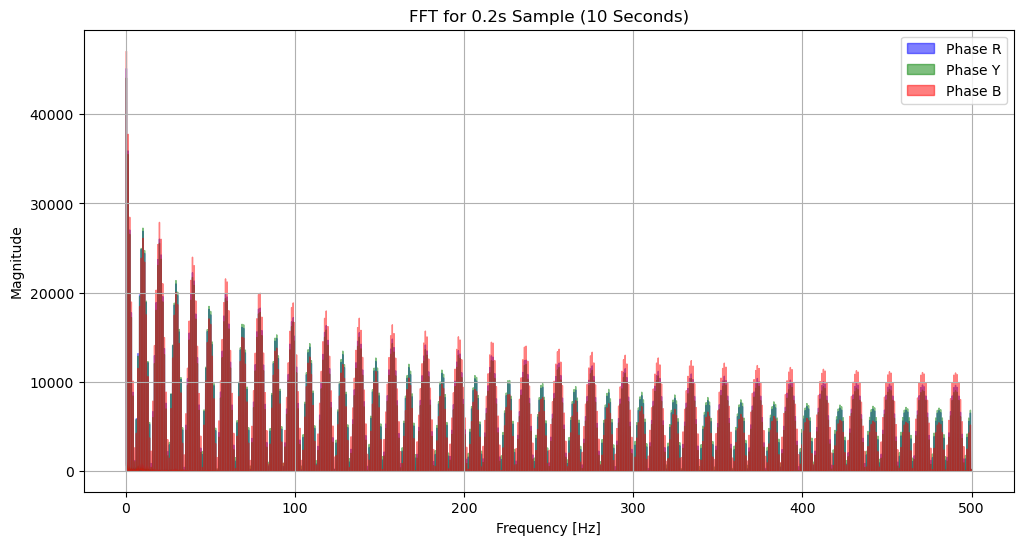

Plotting FFT for 0.5s...


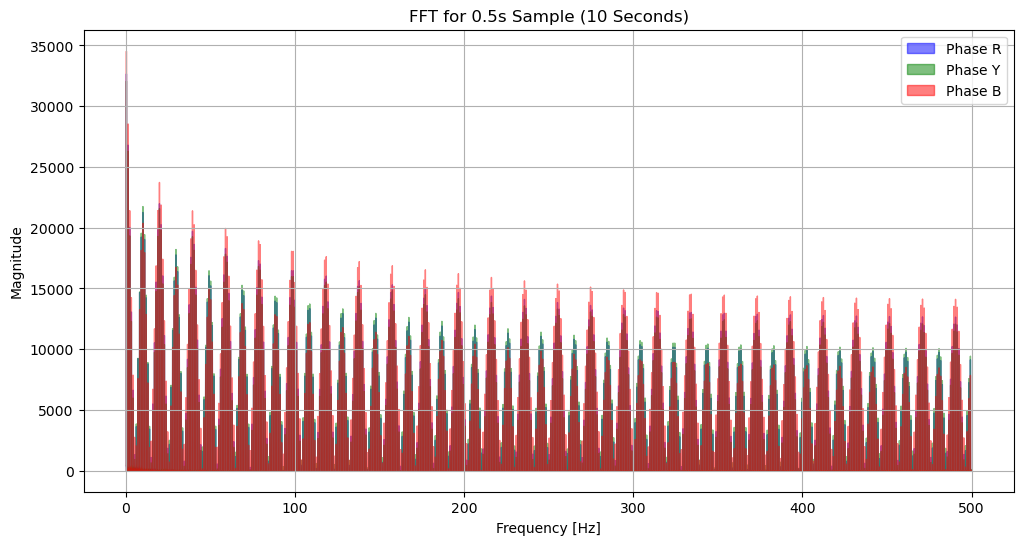

Plotting FFT for 1s...


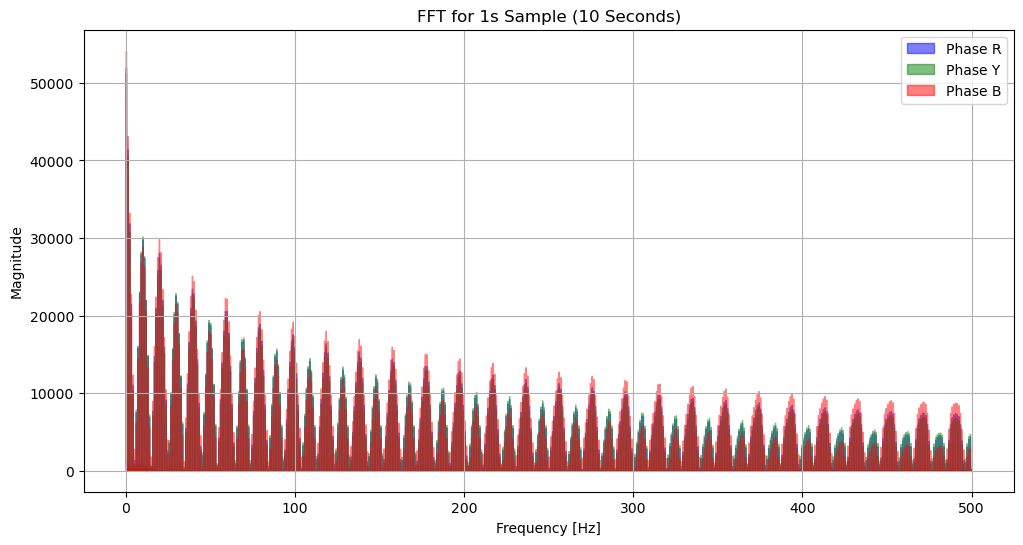

Plotting FFT for 2s...


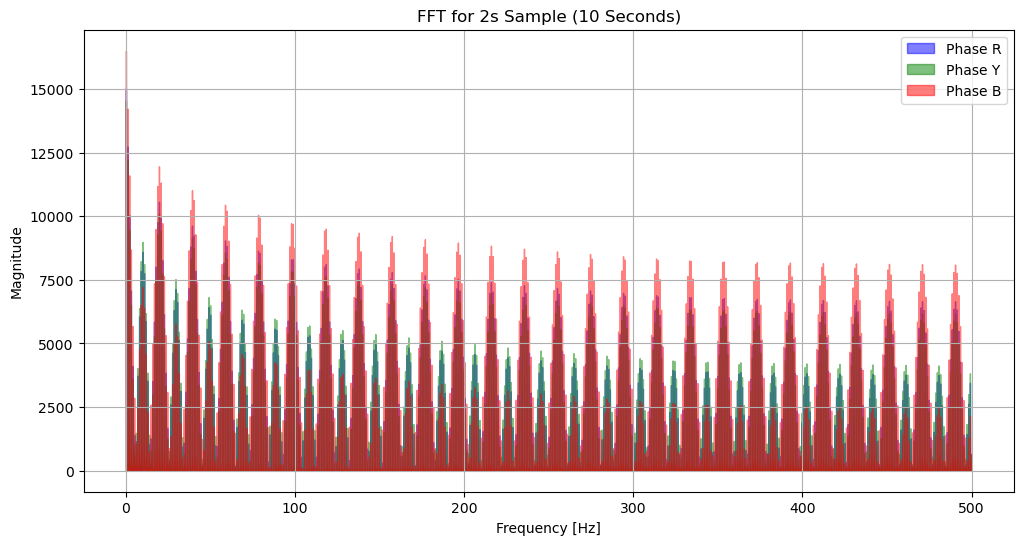

In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft

def load_intermittent_fault_data(base_dir):
    """
    Load raw intermittent fault data from the specified directory.
    """
    intermittent_data = {}
    folders = ["0.2s", "0.5s", "1s", "2s"]

    for folder in folders:
        folder_path = os.path.join(base_dir, folder)
        if not os.path.exists(folder_path):
            print(f"Folder {folder_path} does not exist. Skipping.")
            continue

        for file in os.listdir(folder_path):
            if file.endswith(".csv"):
                file_path = os.path.join(folder_path, file)
                try:
                    # Load the CSV file
                    df = pd.read_csv(file_path, header=None)
                    current_data = df.iloc[:, -3:].values  # Take the last 3 columns (R, Y, B currents)

                    # Store the entire 10-second signal
                    if folder not in intermittent_data:
                        intermittent_data[folder] = []
                    intermittent_data[folder].append(current_data)

                except Exception as e:
                    print(f"Error processing file {file_path}: {e}")

    return intermittent_data

def plot_fft(signal, folder_name):
    """
    Plot the FFT of the entire 10-second signal with blue background and green window.
    """
    fs = 1000  # Sampling frequency (1 kHz)
    n = len(signal)  # Number of samples
    freq = np.fft.fftfreq(n, d=1/fs)  # Frequency axis
    fft_result = np.abs(fft(signal, axis=0))  # Compute FFT for each phase

    # Plot FFT for Phase R
    plt.figure(figsize=(12, 6))
    plt.fill_between(freq[:n//2], 0, fft_result[:n//2, 0], color='blue', alpha=0.5, label="Phase R")
    plt.fill_between(freq[:n//2], 0, fft_result[:n//2, 1], color='green', alpha=0.5, label="Phase Y")
    plt.fill_between(freq[:n//2], 0, fft_result[:n//2, 2], color='red', alpha=0.5, label="Phase B")
    plt.title(f"FFT for {folder_name} Sample (10 Seconds)")
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("Magnitude")
    plt.legend()
    plt.grid()
    plt.show()

# Directory path to intermittent fault data
intermittent_fault_dir = "/home/ani/Downloads/Interturn_wvp/B/"

# Load intermittent fault data
intermittent_data = load_intermittent_fault_data(intermittent_fault_dir)

# Check if data was loaded
if not intermittent_data:
    print("No intermittent fault data found! Check the directory structure and file paths.")
    exit()

# Plot FFT for one sample from each folder
for folder, data_list in intermittent_data.items():
    if data_list:  # Check if data exists for the folder
        print(f"Plotting FFT for {folder}...")
        sample = data_list[0]  # Take the first sample
        plot_fft(sample, folder)

Total files processed: 720
Total FFT segments for Fault: 4320
Total FFT segments for No Fault: 2880
Training FFT segments: 5760
Testing FFT segments: 648
Class 0 (Healthy) samples in training: 2304
Class 1 (Faulty) samples in training: 3456
Class 0 (Healthy) samples in testing: 576
Class 1 (Faulty) samples in testing: 72
Epoch 1/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7440 - loss: 0.4965 - val_accuracy: 0.9002 - val_loss: 0.2733
Epoch 2/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9299 - loss: 0.1974 - val_accuracy: 0.9835 - val_loss: 0.1083
Epoch 3/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9580 - loss: 0.1409 - val_accuracy: 0.9705 - val_loss: 0.1115
Epoch 4/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9595 - loss: 0.1222 - val_accuracy: 0.9575 - val_loss: 0.1394
Epoch 5/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9570 - loss: 0.1321 - val_accuracy: 0.9453 - val_loss: 0.1399
Epoch 6/50
144/144 ━━━━━━━━━━━━━━━━━━

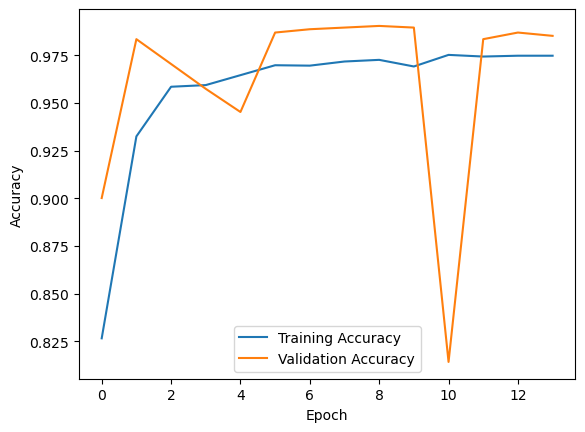

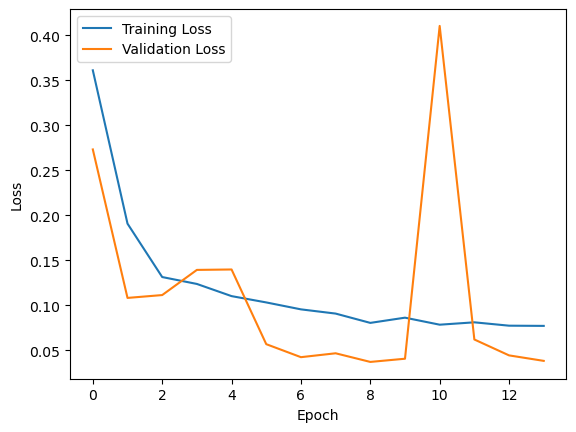

Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 1000, 3)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_20 (Conv1D)              │ (None, 1000, 128)      │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 1000, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 1000, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_21 (Conv1D)              │ (None, 1000, 64)       │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 1000, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 1000, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 64000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 32)             │     2,048,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,248,325 (23.84 MB)

 Trainable params: 2,082,625 (7.94 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 4,165,252 (15.89 MB)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       576
           1       1.00      1.00      1.00        72

    accuracy                           1.00       648
   macro avg       1.00      1.00      1.00       648
weighted avg       1.00      1.00      1.00       648



In [20]:
#TESTING INTERMITTENT FAULT WAVELET sym4
import os
import numpy as np
import pandas as pd
from scipy.fft import fft
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, Dropout, Dense, Flatten, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

def process_file(file_path, data_segments, labels, label, segment_length=1000):
    """
    Process a single file: split into segments, apply FFT, and assign labels.
    """
    try:
        # Load the CSV file
        df = pd.read_csv(file_path, header=None)
        current_data = df.iloc[:, -3:].values  # Take the last 3 columns (R, Y, B currents)

        # Split into 1-second segments (1000 samples per segment)
        segments = [current_data[i:i + segment_length] for i in range(0, len(current_data), segment_length) if i + segment_length <= len(current_data)]

        # Perform FFT on each segment and keep the shape as (segment_length, 3)
        for segment in segments:
            fft_result = np.abs(fft(segment, axis=0))  # Apply FFT to each phase (R, Y, B)
            data_segments.append(fft_result)  # Shape: (segment_length, 3)
            labels.append(label)

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
    
    return data_segments, labels

def load_intermittent_fault_data(base_dir, segment_length=1000):
    """
    Load intermittent fault data from the specified directory and extract windows.
    """
    intermittent_data = []
    intermittent_labels = []

    # Define window extraction logic for each folder
    window_rules = {
        "0.2s": [(1000, 2000)],  # 1s to 2s
        "0.5s": [(1000, 2000)],  # 1s to 2s
        "1s": [(600, 1600), (1600, 2600)],  # 0.6s to 1.6s and 1.6s to 2.6s
        "2s": [(600, 1600), (2400, 3400)],  # 0.6s to 1.6s and 2.4s to 3.4s
    }

    for folder, windows in window_rules.items():
        folder_path = os.path.join(base_dir, folder)
        if not os.path.exists(folder_path):
            print(f"Folder {folder_path} does not exist. Skipping.")
            continue

        for file in os.listdir(folder_path):
            if file.endswith(".csv"):
                file_path = os.path.join(folder_path, file)
                try:
                    # Load the CSV file
                    df = pd.read_csv(file_path, header=None)
                    current_data = df.iloc[:, -3:].values  # Take the last 3 columns (R, Y, B currents)

                    # Extract the specified windows
                    for start, end in windows:
                        segment = current_data[start:end]
                        if len(segment) == segment_length:
                            fft_result = np.abs(fft(segment, axis=0))  # Apply FFT
                            intermittent_data.append(fft_result)
                            intermittent_labels.append(1)  # Label for fault

                except Exception as e:
                    print(f"Error processing file {file_path}: {e}")

    return np.array(intermittent_data), np.array(intermittent_labels)

def load_and_preprocess_data(data_dir, segment_length=1000, test_size=0.2, random_state=42):
    """
    Load and preprocess data from the directory, splitting fault and no-fault data separately.
    """
    fault_data = []
    no_fault_data = []
    fault_labels = []
    no_fault_labels = []
    file_count = 0  # Initialize file counter

    # Iterate over load levels (e.g., 0.5_A, 1_A, etc.)
    for load in os.listdir(data_dir):
        load_path = os.path.join(data_dir, load)
        if not os.path.isdir(load_path):
            continue

        # Check for Fault and No_Fault directories
        for condition in ["Fault", "No_Fault"]:
            condition_path = os.path.join(load_path, condition)
            if condition == "Fault":  # Handle fault conditions
                for phase in ["P3"]:  # Only process P1 for this NN
                    phase_path = os.path.join(condition_path, phase)
                    if os.path.exists(phase_path):
                        for file in os.listdir(phase_path):
                            if file.endswith(".csv"):
                                file_count += 1  # Increment the file counter
                                file_path = os.path.join(phase_path, file)
                                fault_data, fault_labels = process_file(file_path, fault_data, fault_labels, label=1, segment_length=segment_length)
            elif condition == "No_Fault":  # Handle no fault conditions
                if os.path.exists(condition_path):
                    for file in os.listdir(condition_path):
                        if file.endswith(".csv"):
                            file_count += 1  # Increment the file counter
                            file_path = os.path.join(condition_path, file)
                            no_fault_data, no_fault_labels = process_file(file_path, no_fault_data, no_fault_labels, label=0, segment_length=segment_length)

    print(f"Total files processed: {file_count}")  # Print the total file count
    print(f"Total FFT segments for Fault: {len(fault_data)}")
    print(f"Total FFT segments for No Fault: {len(no_fault_data)}")

    # Convert to numpy arrays
    fault_data = np.array(fault_data)
    no_fault_data = np.array(no_fault_data)
    fault_labels = np.array(fault_labels)
    no_fault_labels = np.array(no_fault_labels)

    # Split fault data into train and test sets
    X_fault_train, _, y_fault_train, _ = train_test_split(
        fault_data, fault_labels, test_size=test_size, random_state=random_state
    )

    # Split no-fault data into train and test sets
    X_no_fault_train, X_no_fault_test, y_no_fault_train, y_no_fault_test = train_test_split(
        no_fault_data, no_fault_labels, test_size=test_size, random_state=random_state
    )

    # Load intermittent fault data for testing
    intermittent_fault_dir = "/home/ani/Project/Interfault_sym4/B/"
    X_intermittent_fault, y_intermittent_fault = load_intermittent_fault_data(intermittent_fault_dir, segment_length=segment_length)

    # Combine fault and no-fault data for training
    X_train = np.concatenate((X_fault_train, X_no_fault_train), axis=0)
    y_train = np.concatenate((y_fault_train, y_no_fault_train), axis=0)

    # Use intermittent fault data and no-fault test data for testing
    X_test = np.concatenate((X_intermittent_fault, X_no_fault_test), axis=0)
    y_test = np.concatenate((y_intermittent_fault, y_no_fault_test), axis=0)

    # Shuffle the training and testing data
    train_indices = np.arange(len(X_train))
    test_indices = np.arange(len(X_test))
    np.random.shuffle(train_indices)
    np.random.shuffle(test_indices)

    X_train = X_train[train_indices]
    y_train = y_train[train_indices]
    X_test = X_test[test_indices]
    y_test = y_test[test_indices]

    return X_train, X_test, y_train, y_test

# Directory path to data
base_dir = "/home/ani/DataNN/5kVA/Load"

# Load and preprocess data with 1-second intervals (1000 samples per segment)
segment_length = 1000  # Change to 500 if you want 500 samples per segment
X_train, X_test, y_train, y_test = load_and_preprocess_data(base_dir, segment_length=segment_length)

# Check if data was loaded
if X_train.size == 0 or X_test.size == 0:
    print("No data found! Check the directory structure and file paths.")
    exit()

# Print training and testing FFT segment counts
print(f"Training FFT segments: {len(X_train)}")
print(f"Testing FFT segments: {len(X_test)}")

# Check class distribution
print(f"Class 0 (Healthy) samples in training: {np.sum(y_train == 0)}")
print(f"Class 1 (Faulty) samples in training: {np.sum(y_train == 1)}")
print(f"Class 0 (Healthy) samples in testing: {np.sum(y_test == 0)}")
print(f"Class 1 (Faulty) samples in testing: {np.sum(y_test == 1)}")

# Define the CNN model with a bottleneck layer
def build_cnn_model(input_shape):
    inputs = Input(shape=input_shape)

    # Convolutional layers
    x = Conv1D(128, kernel_size=3, padding='same', activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting

    x = Conv1D(64, kernel_size=4, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting

    x = Flatten()(x)

    # Bottleneck layer
    x = Dense(32)(x)  # Bottleneck size = 32
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting
    x = Activation('relu')(x)

    # Output layer
    outputs = Dense(1, activation='sigmoid')(x)  # Binary classification

    # Create the model
    model = Model(inputs=inputs, outputs=outputs)
    return model

# Build the model
input_shape = (segment_length, 3)  # Input shape: (segment_length, 3)
cnn_model = build_cnn_model(input_shape)

# Compile the model
cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Add early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Add class weighting to address imbalance
class_weights = {0: 1.2, 1: 0.8}  # Adjust weights based on class imbalance

# Train the model with early stopping and class weighting
history = cnn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    class_weight=class_weights
)

# Evaluate the model
loss, accuracy = cnn_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
cnn_model.summary()
# Additional evaluation
y_pred = (cnn_model.predict(X_test) > 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Plotting FFT for 0.2s...


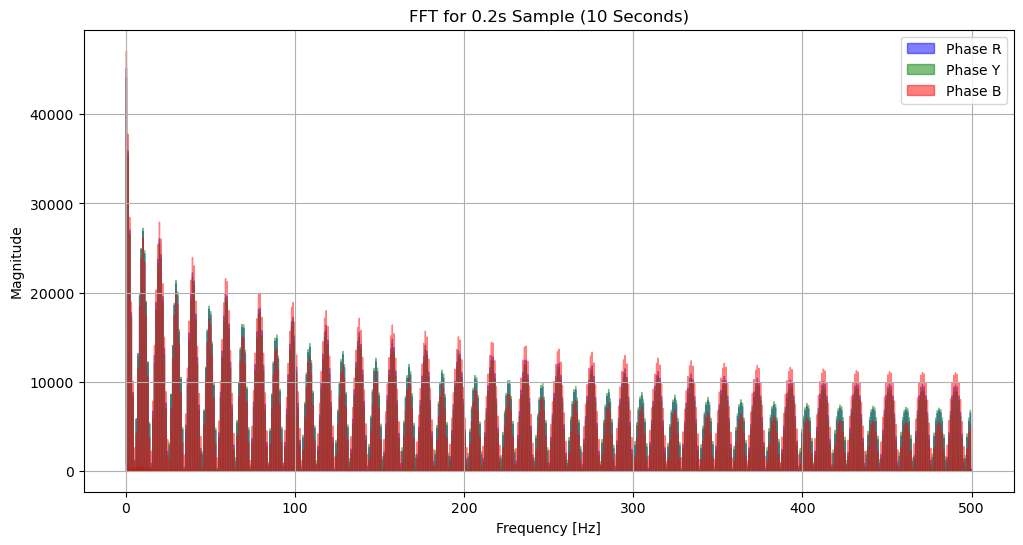

Plotting FFT for 0.5s...


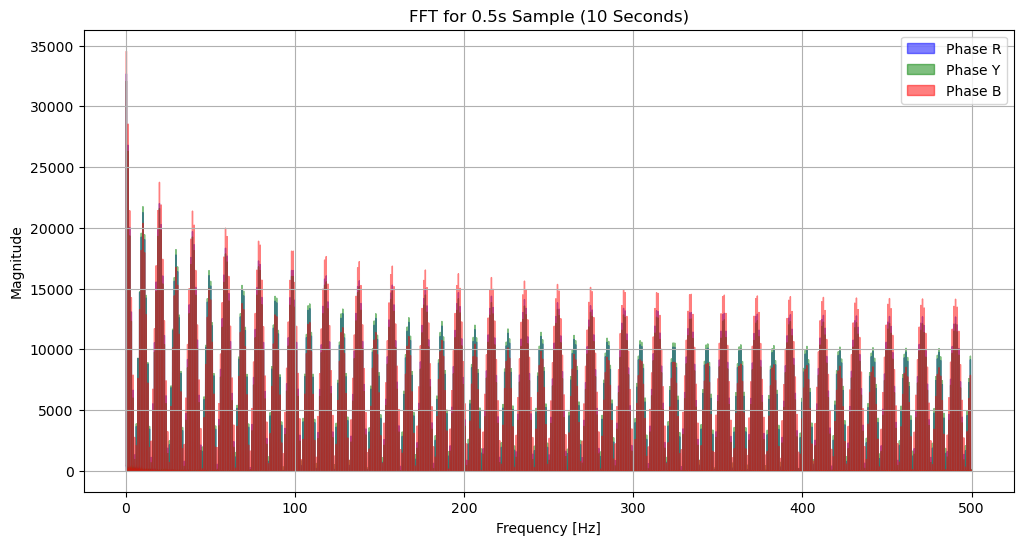

Plotting FFT for 1s...


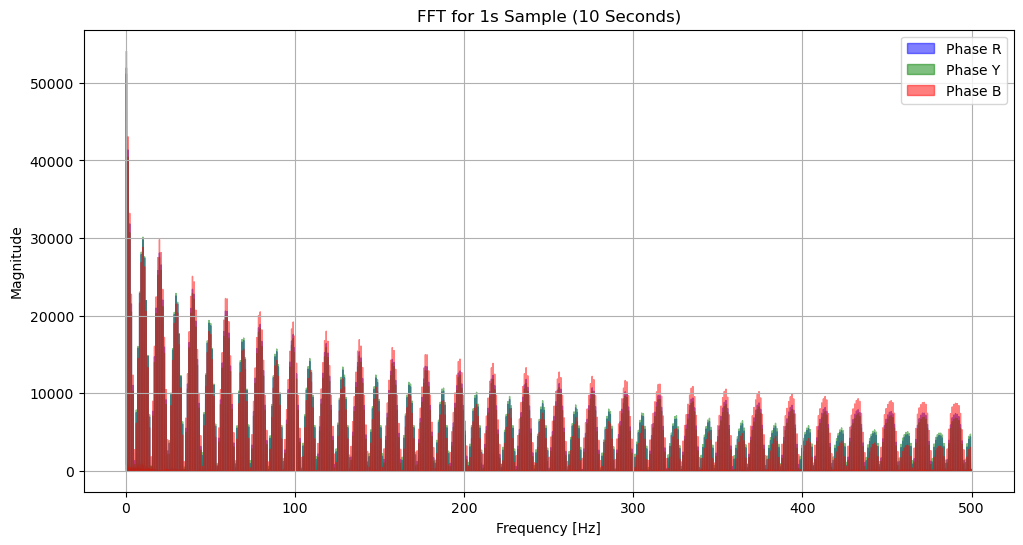

Plotting FFT for 2s...


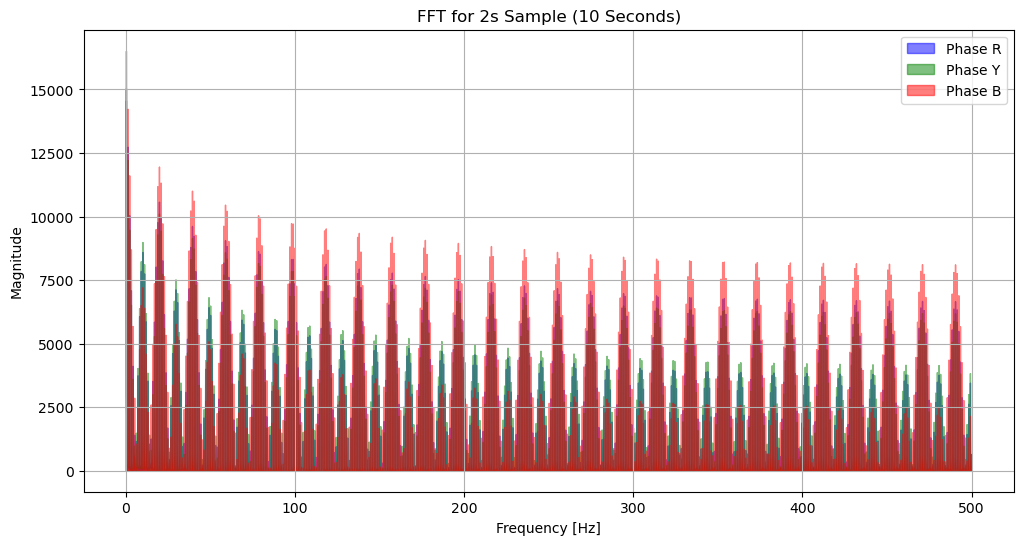

In [21]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft

def load_intermittent_fault_data(base_dir):
    """
    Load raw intermittent fault data from the specified directory.
    """
    intermittent_data = {}
    folders = ["0.2s", "0.5s", "1s", "2s"]

    for folder in folders:
        folder_path = os.path.join(base_dir, folder)
        if not os.path.exists(folder_path):
            print(f"Folder {folder_path} does not exist. Skipping.")
            continue

        for file in os.listdir(folder_path):
            if file.endswith(".csv"):
                file_path = os.path.join(folder_path, file)
                try:
                    # Load the CSV file
                    df = pd.read_csv(file_path, header=None)
                    current_data = df.iloc[:, -3:].values  # Take the last 3 columns (R, Y, B currents)

                    # Store the entire 10-second signal
                    if folder not in intermittent_data:
                        intermittent_data[folder] = []
                    intermittent_data[folder].append(current_data)

                except Exception as e:
                    print(f"Error processing file {file_path}: {e}")

    return intermittent_data

def plot_fft(signal, folder_name):
    """
    Plot the FFT of the entire 10-second signal with blue background and green window.
    """
    fs = 1000  # Sampling frequency (1 kHz)
    n = len(signal)  # Number of samples
    freq = np.fft.fftfreq(n, d=1/fs)  # Frequency axis
    fft_result = np.abs(fft(signal, axis=0))  # Compute FFT for each phase

    # Plot FFT for Phase R
    plt.figure(figsize=(12, 6))
    plt.fill_between(freq[:n//2], 0, fft_result[:n//2, 0], color='blue', alpha=0.5, label="Phase R")
    plt.fill_between(freq[:n//2], 0, fft_result[:n//2, 1], color='green', alpha=0.5, label="Phase Y")
    plt.fill_between(freq[:n//2], 0, fft_result[:n//2, 2], color='red', alpha=0.5, label="Phase B")
    plt.title(f"FFT for {folder_name} Sample (10 Seconds)")
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("Magnitude")
    plt.legend()
    plt.grid()
    plt.show()

# Directory path to intermittent fault data
intermittent_fault_dir = "/home/ani/Project/Interfault_sym4/B/"

# Load intermittent fault data
intermittent_data = load_intermittent_fault_data(intermittent_fault_dir)

# Check if data was loaded
if not intermittent_data:
    print("No intermittent fault data found! Check the directory structure and file paths.")
    exit()

# Plot FFT for one sample from each folder
for folder, data_list in intermittent_data.items():
    if data_list:  # Check if data exists for the folder
        print(f"Plotting FFT for {folder}...")
        sample = data_list[0]  # Take the first sample
        plot_fft(sample, folder)

Total files processed: 720
Total FFT segments for Fault: 4320
Total FFT segments for No Fault: 2880
Training FFT segments: 5760
Testing FFT segments: 648
Class 0 (Healthy) samples in training: 2304
Class 1 (Faulty) samples in training: 3456
Class 0 (Healthy) samples in testing: 576
Class 1 (Faulty) samples in testing: 72
Epoch 1/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7540 - loss: 0.5681 - val_accuracy: 0.6901 - val_loss: 0.5205
Epoch 2/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9163 - loss: 0.2212 - val_accuracy: 0.8620 - val_loss: 0.2964
Epoch 3/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9432 - loss: 0.1680 - val_accuracy: 0.9549 - val_loss: 0.1469
Epoch 4/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9499 - loss: 0.1362 - val_accuracy: 0.9835 - val_loss: 0.0686
Epoch 5/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9685 - loss: 0.1166 - val_accuracy: 0.9852 - val_loss: 0.0725
Epoch 6/50
144/144 ━━━━━━━━━━━━━━━━━━

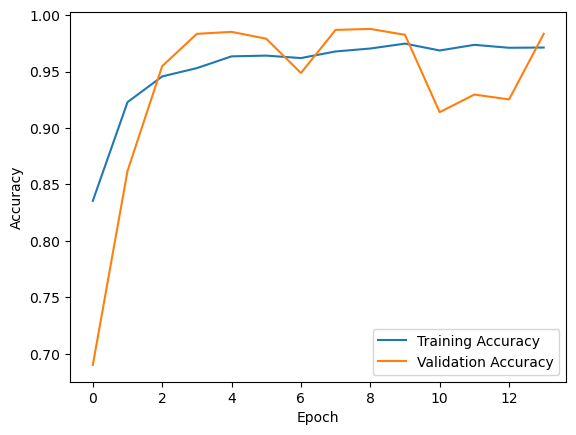

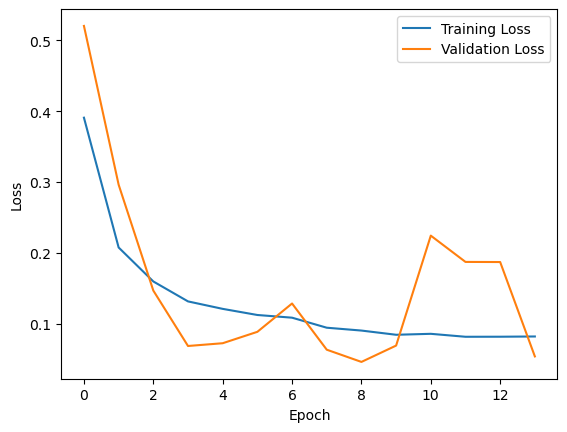

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 1000, 3)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_22 (Conv1D)              │ (None, 1000, 128)      │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 1000, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 1000, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_23 (Conv1D)              │ (None, 1000, 64)       │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 1000, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 1000, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 64000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 32)             │     2,048,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,248,325 (23.84 MB)

 Trainable params: 2,082,625 (7.94 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 4,165,252 (15.89 MB)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       576
           1       0.99      1.00      0.99        72

    accuracy                           1.00       648
   macro avg       0.99      1.00      1.00       648
weighted avg       1.00      1.00      1.00       648



In [22]:
#TESTING INTERMITTENT FAULT WAVELET BIOR2.2
import os
import numpy as np
import pandas as pd
from scipy.fft import fft
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, Dropout, Dense, Flatten, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

def process_file(file_path, data_segments, labels, label, segment_length=1000):
    """
    Process a single file: split into segments, apply FFT, and assign labels.
    """
    try:
        # Load the CSV file
        df = pd.read_csv(file_path, header=None)
        current_data = df.iloc[:, -3:].values  # Take the last 3 columns (R, Y, B currents)

        # Split into 1-second segments (1000 samples per segment)
        segments = [current_data[i:i + segment_length] for i in range(0, len(current_data), segment_length) if i + segment_length <= len(current_data)]

        # Perform FFT on each segment and keep the shape as (segment_length, 3)
        for segment in segments:
            fft_result = np.abs(fft(segment, axis=0))  # Apply FFT to each phase (R, Y, B)
            data_segments.append(fft_result)  # Shape: (segment_length, 3)
            labels.append(label)

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
    
    return data_segments, labels

def load_intermittent_fault_data(base_dir, segment_length=1000):
    """
    Load intermittent fault data from the specified directory and extract windows.
    """
    intermittent_data = []
    intermittent_labels = []

    # Define window extraction logic for each folder
    window_rules = {
        "0.2s": [(1000, 2000)],  # 1s to 2s
        "0.5s": [(1000, 2000)],  # 1s to 2s
        "1s": [(600, 1600), (1600, 2600)],  # 0.6s to 1.6s and 1.6s to 2.6s
        "2s": [(600, 1600), (2400, 3400)],  # 0.6s to 1.6s and 2.4s to 3.4s
    }

    for folder, windows in window_rules.items():
        folder_path = os.path.join(base_dir, folder)
        if not os.path.exists(folder_path):
            print(f"Folder {folder_path} does not exist. Skipping.")
            continue

        for file in os.listdir(folder_path):
            if file.endswith(".csv"):
                file_path = os.path.join(folder_path, file)
                try:
                    # Load the CSV file
                    df = pd.read_csv(file_path, header=None)
                    current_data = df.iloc[:, -3:].values  # Take the last 3 columns (R, Y, B currents)

                    # Extract the specified windows
                    for start, end in windows:
                        segment = current_data[start:end]
                        if len(segment) == segment_length:
                            fft_result = np.abs(fft(segment, axis=0))  # Apply FFT
                            intermittent_data.append(fft_result)
                            intermittent_labels.append(1)  # Label for fault

                except Exception as e:
                    print(f"Error processing file {file_path}: {e}")

    return np.array(intermittent_data), np.array(intermittent_labels)

def load_and_preprocess_data(data_dir, segment_length=1000, test_size=0.2, random_state=42):
    """
    Load and preprocess data from the directory, splitting fault and no-fault data separately.
    """
    fault_data = []
    no_fault_data = []
    fault_labels = []
    no_fault_labels = []
    file_count = 0  # Initialize file counter

    # Iterate over load levels (e.g., 0.5_A, 1_A, etc.)
    for load in os.listdir(data_dir):
        load_path = os.path.join(data_dir, load)
        if not os.path.isdir(load_path):
            continue

        # Check for Fault and No_Fault directories
        for condition in ["Fault", "No_Fault"]:
            condition_path = os.path.join(load_path, condition)
            if condition == "Fault":  # Handle fault conditions
                for phase in ["P3"]:  # Only process P1 for this NN
                    phase_path = os.path.join(condition_path, phase)
                    if os.path.exists(phase_path):
                        for file in os.listdir(phase_path):
                            if file.endswith(".csv"):
                                file_count += 1  # Increment the file counter
                                file_path = os.path.join(phase_path, file)
                                fault_data, fault_labels = process_file(file_path, fault_data, fault_labels, label=1, segment_length=segment_length)
            elif condition == "No_Fault":  # Handle no fault conditions
                if os.path.exists(condition_path):
                    for file in os.listdir(condition_path):
                        if file.endswith(".csv"):
                            file_count += 1  # Increment the file counter
                            file_path = os.path.join(condition_path, file)
                            no_fault_data, no_fault_labels = process_file(file_path, no_fault_data, no_fault_labels, label=0, segment_length=segment_length)

    print(f"Total files processed: {file_count}")  # Print the total file count
    print(f"Total FFT segments for Fault: {len(fault_data)}")
    print(f"Total FFT segments for No Fault: {len(no_fault_data)}")

    # Convert to numpy arrays
    fault_data = np.array(fault_data)
    no_fault_data = np.array(no_fault_data)
    fault_labels = np.array(fault_labels)
    no_fault_labels = np.array(no_fault_labels)

    # Split fault data into train and test sets
    X_fault_train, _, y_fault_train, _ = train_test_split(
        fault_data, fault_labels, test_size=test_size, random_state=random_state
    )

    # Split no-fault data into train and test sets
    X_no_fault_train, X_no_fault_test, y_no_fault_train, y_no_fault_test = train_test_split(
        no_fault_data, no_fault_labels, test_size=test_size, random_state=random_state
    )

    # Load intermittent fault data for testing
    intermittent_fault_dir = "/home/ani/Project/Interfault_bior2.2/B/"
    X_intermittent_fault, y_intermittent_fault = load_intermittent_fault_data(intermittent_fault_dir, segment_length=segment_length)

    # Combine fault and no-fault data for training
    X_train = np.concatenate((X_fault_train, X_no_fault_train), axis=0)
    y_train = np.concatenate((y_fault_train, y_no_fault_train), axis=0)

    # Use intermittent fault data and no-fault test data for testing
    X_test = np.concatenate((X_intermittent_fault, X_no_fault_test), axis=0)
    y_test = np.concatenate((y_intermittent_fault, y_no_fault_test), axis=0)

    # Shuffle the training and testing data
    train_indices = np.arange(len(X_train))
    test_indices = np.arange(len(X_test))
    np.random.shuffle(train_indices)
    np.random.shuffle(test_indices)

    X_train = X_train[train_indices]
    y_train = y_train[train_indices]
    X_test = X_test[test_indices]
    y_test = y_test[test_indices]

    return X_train, X_test, y_train, y_test

# Directory path to data
base_dir = "/home/ani/DataNN/5kVA/Load"

# Load and preprocess data with 1-second intervals (1000 samples per segment)
segment_length = 1000  # Change to 500 if you want 500 samples per segment
X_train, X_test, y_train, y_test = load_and_preprocess_data(base_dir, segment_length=segment_length)

# Check if data was loaded
if X_train.size == 0 or X_test.size == 0:
    print("No data found! Check the directory structure and file paths.")
    exit()

# Print training and testing FFT segment counts
print(f"Training FFT segments: {len(X_train)}")
print(f"Testing FFT segments: {len(X_test)}")

# Check class distribution
print(f"Class 0 (Healthy) samples in training: {np.sum(y_train == 0)}")
print(f"Class 1 (Faulty) samples in training: {np.sum(y_train == 1)}")
print(f"Class 0 (Healthy) samples in testing: {np.sum(y_test == 0)}")
print(f"Class 1 (Faulty) samples in testing: {np.sum(y_test == 1)}")

# Define the CNN model with a bottleneck layer
def build_cnn_model(input_shape):
    inputs = Input(shape=input_shape)

    # Convolutional layers
    x = Conv1D(128, kernel_size=3, padding='same', activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting

    x = Conv1D(64, kernel_size=4, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting

    x = Flatten()(x)

    # Bottleneck layer
    x = Dense(32)(x)  # Bottleneck size = 32
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting
    x = Activation('relu')(x)

    # Output layer
    outputs = Dense(1, activation='sigmoid')(x)  # Binary classification

    # Create the model
    model = Model(inputs=inputs, outputs=outputs)
    return model

# Build the model
input_shape = (segment_length, 3)  # Input shape: (segment_length, 3)
cnn_model = build_cnn_model(input_shape)

# Compile the model
cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Add early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Add class weighting to address imbalance
class_weights = {0: 1.2, 1: 0.8}  # Adjust weights based on class imbalance

# Train the model with early stopping and class weighting
history = cnn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    class_weight=class_weights
)

# Evaluate the model
loss, accuracy = cnn_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
cnn_model.summary()
# Additional evaluation
y_pred = (cnn_model.predict(X_test) > 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Plotting FFT for 0.2s...


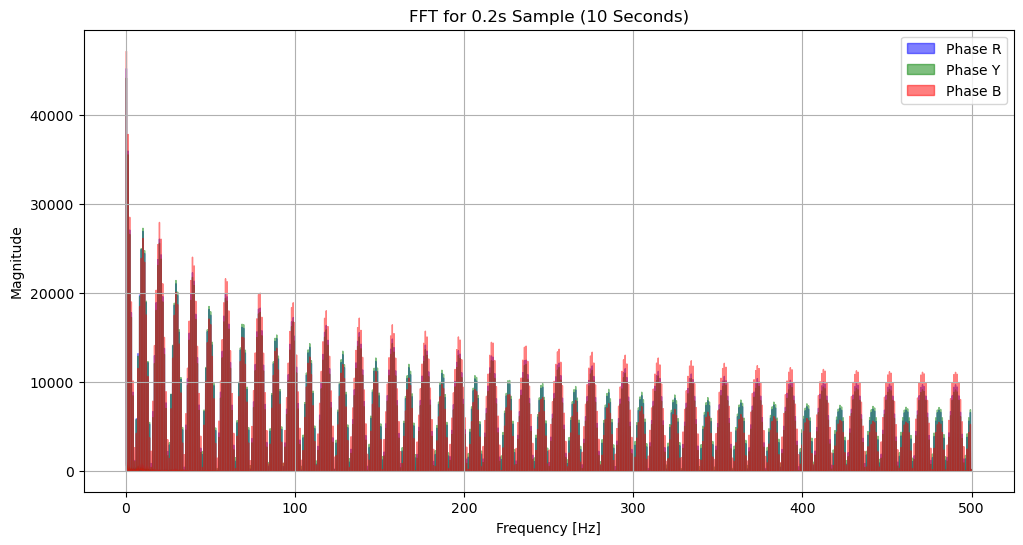

Plotting FFT for 0.5s...


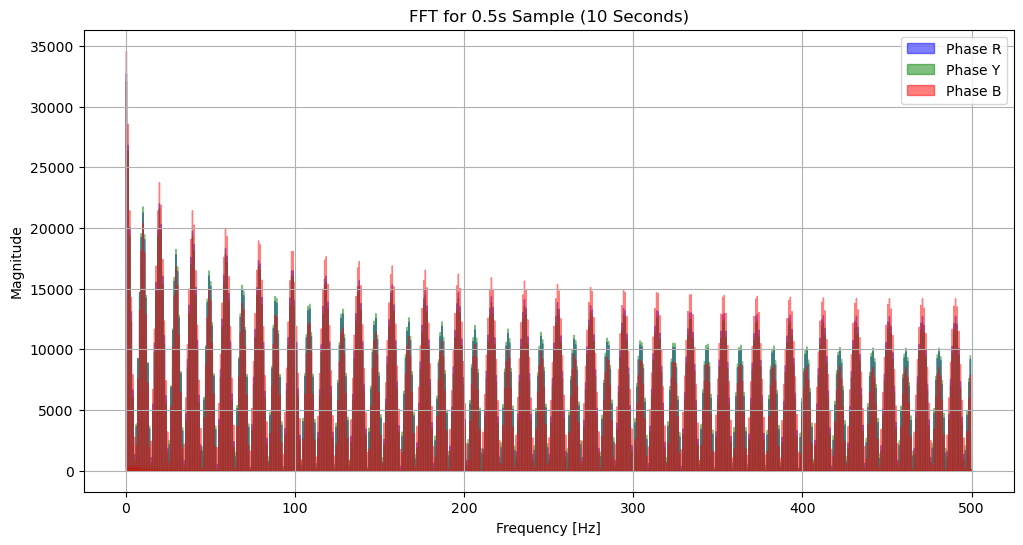

Plotting FFT for 1s...


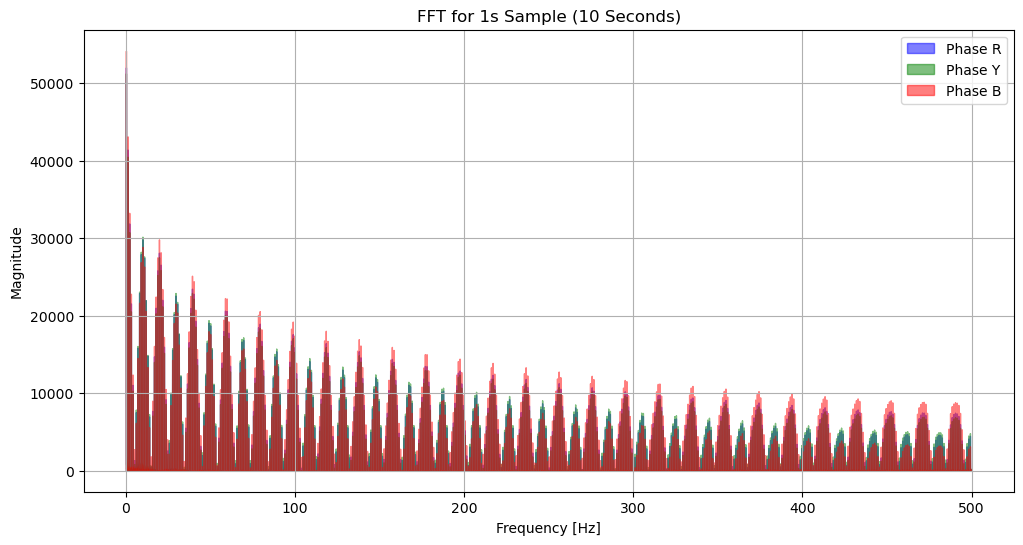

Plotting FFT for 2s...


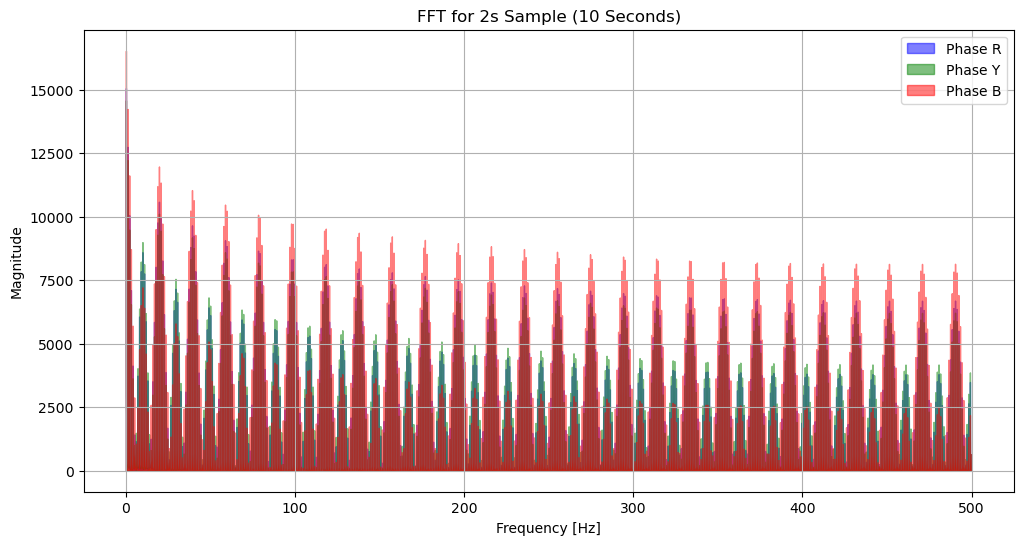

In [23]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft

def load_intermittent_fault_data(base_dir):
    """
    Load raw intermittent fault data from the specified directory.
    """
    intermittent_data = {}
    folders = ["0.2s", "0.5s", "1s", "2s"]

    for folder in folders:
        folder_path = os.path.join(base_dir, folder)
        if not os.path.exists(folder_path):
            print(f"Folder {folder_path} does not exist. Skipping.")
            continue

        for file in os.listdir(folder_path):
            if file.endswith(".csv"):
                file_path = os.path.join(folder_path, file)
                try:
                    # Load the CSV file
                    df = pd.read_csv(file_path, header=None)
                    current_data = df.iloc[:, -3:].values  # Take the last 3 columns (R, Y, B currents)

                    # Store the entire 10-second signal
                    if folder not in intermittent_data:
                        intermittent_data[folder] = []
                    intermittent_data[folder].append(current_data)

                except Exception as e:
                    print(f"Error processing file {file_path}: {e}")

    return intermittent_data

def plot_fft(signal, folder_name):
    """
    Plot the FFT of the entire 10-second signal with blue background and green window.
    """
    fs = 1000  # Sampling frequency (1 kHz)
    n = len(signal)  # Number of samples
    freq = np.fft.fftfreq(n, d=1/fs)  # Frequency axis
    fft_result = np.abs(fft(signal, axis=0))  # Compute FFT for each phase

    # Plot FFT for Phase R
    plt.figure(figsize=(12, 6))
    plt.fill_between(freq[:n//2], 0, fft_result[:n//2, 0], color='blue', alpha=0.5, label="Phase R")
    plt.fill_between(freq[:n//2], 0, fft_result[:n//2, 1], color='green', alpha=0.5, label="Phase Y")
    plt.fill_between(freq[:n//2], 0, fft_result[:n//2, 2], color='red', alpha=0.5, label="Phase B")
    plt.title(f"FFT for {folder_name} Sample (10 Seconds)")
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("Magnitude")
    plt.legend()
    plt.grid()
    plt.show()

# Directory path to intermittent fault data
intermittent_fault_dir = "/home/ani/Project/Interfault_bior2.2/B/"

# Load intermittent fault data
intermittent_data = load_intermittent_fault_data(intermittent_fault_dir)

# Check if data was loaded
if not intermittent_data:
    print("No intermittent fault data found! Check the directory structure and file paths.")
    exit()

# Plot FFT for one sample from each folder
for folder, data_list in intermittent_data.items():
    if data_list:  # Check if data exists for the folder
        print(f"Plotting FFT for {folder}...")
        sample = data_list[0]  # Take the first sample
        plot_fft(sample, folder)

Total files processed: 720
Total FFT segments for Fault: 4320
Total FFT segments for No Fault: 2880
Training FFT segments: 5760
Testing FFT segments: 648
Class 0 (Healthy) samples in training: 2304
Class 1 (Faulty) samples in training: 3456
Class 0 (Healthy) samples in testing: 576
Class 1 (Faulty) samples in testing: 72
Epoch 1/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7308 - loss: 0.5320 - val_accuracy: 0.9175 - val_loss: 0.3084
Epoch 2/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9308 - loss: 0.2103 - val_accuracy: 0.8906 - val_loss: 0.2467
Epoch 3/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9491 - loss: 0.1555 - val_accuracy: 0.9696 - val_loss: 0.1160
Epoch 4/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9575 - loss: 0.1284 - val_accuracy: 0.9722 - val_loss: 0.1108
Epoch 5/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9547 - loss: 0.1286 - val_accuracy: 0.9852 - val_loss: 0.0768
Epoch 6/50
144/144 ━━━━━━━━━━━━━━━━━━

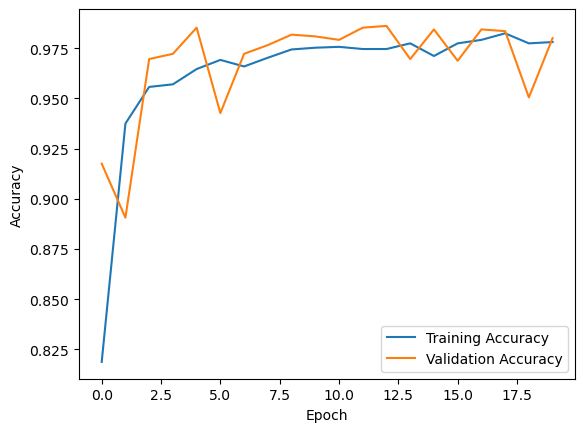

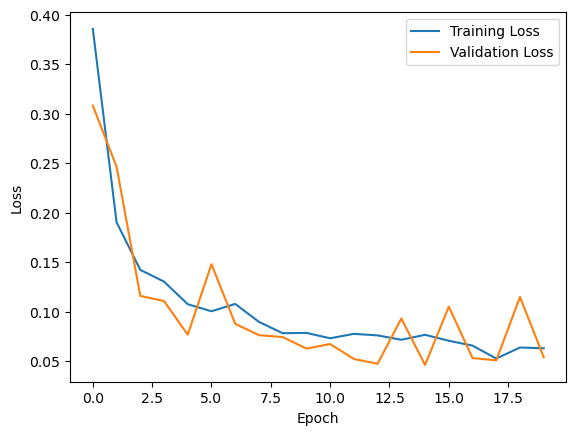

Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 1000, 3)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_24 (Conv1D)              │ (None, 1000, 128)      │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 1000, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 1000, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_25 (Conv1D)              │ (None, 1000, 64)       │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 1000, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 1000, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (None, 64000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 32)             │     2,048,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,248,325 (23.84 MB)

 Trainable params: 2,082,625 (7.94 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 4,165,252 (15.89 MB)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       576
           1       0.99      1.00      0.99        72

    accuracy                           1.00       648
   macro avg       0.99      1.00      1.00       648
weighted avg       1.00      1.00      1.00       648



In [24]:
#TESTING INTERMITTENT FAULT WAVELET COIF1
import os
import numpy as np
import pandas as pd
from scipy.fft import fft
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, Dropout, Dense, Flatten, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

def process_file(file_path, data_segments, labels, label, segment_length=1000):
    """
    Process a single file: split into segments, apply FFT, and assign labels.
    """
    try:
        # Load the CSV file
        df = pd.read_csv(file_path, header=None)
        current_data = df.iloc[:, -3:].values  # Take the last 3 columns (R, Y, B currents)

        # Split into 1-second segments (1000 samples per segment)
        segments = [current_data[i:i + segment_length] for i in range(0, len(current_data), segment_length) if i + segment_length <= len(current_data)]

        # Perform FFT on each segment and keep the shape as (segment_length, 3)
        for segment in segments:
            fft_result = np.abs(fft(segment, axis=0))  # Apply FFT to each phase (R, Y, B)
            data_segments.append(fft_result)  # Shape: (segment_length, 3)
            labels.append(label)

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
    
    return data_segments, labels

def load_intermittent_fault_data(base_dir, segment_length=1000):
    """
    Load intermittent fault data from the specified directory and extract windows.
    """
    intermittent_data = []
    intermittent_labels = []

    # Define window extraction logic for each folder
    window_rules = {
        "0.2s": [(1000, 2000)],  # 1s to 2s
        "0.5s": [(1000, 2000)],  # 1s to 2s
        "1s": [(600, 1600), (1600, 2600)],  # 0.6s to 1.6s and 1.6s to 2.6s
        "2s": [(600, 1600), (2400, 3400)],  # 0.6s to 1.6s and 2.4s to 3.4s
    }

    for folder, windows in window_rules.items():
        folder_path = os.path.join(base_dir, folder)
        if not os.path.exists(folder_path):
            print(f"Folder {folder_path} does not exist. Skipping.")
            continue

        for file in os.listdir(folder_path):
            if file.endswith(".csv"):
                file_path = os.path.join(folder_path, file)
                try:
                    # Load the CSV file
                    df = pd.read_csv(file_path, header=None)
                    current_data = df.iloc[:, -3:].values  # Take the last 3 columns (R, Y, B currents)

                    # Extract the specified windows
                    for start, end in windows:
                        segment = current_data[start:end]
                        if len(segment) == segment_length:
                            fft_result = np.abs(fft(segment, axis=0))  # Apply FFT
                            intermittent_data.append(fft_result)
                            intermittent_labels.append(1)  # Label for fault

                except Exception as e:
                    print(f"Error processing file {file_path}: {e}")

    return np.array(intermittent_data), np.array(intermittent_labels)

def load_and_preprocess_data(data_dir, segment_length=1000, test_size=0.2, random_state=42):
    """
    Load and preprocess data from the directory, splitting fault and no-fault data separately.
    """
    fault_data = []
    no_fault_data = []
    fault_labels = []
    no_fault_labels = []
    file_count = 0  # Initialize file counter

    # Iterate over load levels (e.g., 0.5_A, 1_A, etc.)
    for load in os.listdir(data_dir):
        load_path = os.path.join(data_dir, load)
        if not os.path.isdir(load_path):
            continue

        # Check for Fault and No_Fault directories
        for condition in ["Fault", "No_Fault"]:
            condition_path = os.path.join(load_path, condition)
            if condition == "Fault":  # Handle fault conditions
                for phase in ["P3"]:  # Only process P1 for this NN
                    phase_path = os.path.join(condition_path, phase)
                    if os.path.exists(phase_path):
                        for file in os.listdir(phase_path):
                            if file.endswith(".csv"):
                                file_count += 1  # Increment the file counter
                                file_path = os.path.join(phase_path, file)
                                fault_data, fault_labels = process_file(file_path, fault_data, fault_labels, label=1, segment_length=segment_length)
            elif condition == "No_Fault":  # Handle no fault conditions
                if os.path.exists(condition_path):
                    for file in os.listdir(condition_path):
                        if file.endswith(".csv"):
                            file_count += 1  # Increment the file counter
                            file_path = os.path.join(condition_path, file)
                            no_fault_data, no_fault_labels = process_file(file_path, no_fault_data, no_fault_labels, label=0, segment_length=segment_length)

    print(f"Total files processed: {file_count}")  # Print the total file count
    print(f"Total FFT segments for Fault: {len(fault_data)}")
    print(f"Total FFT segments for No Fault: {len(no_fault_data)}")

    # Convert to numpy arrays
    fault_data = np.array(fault_data)
    no_fault_data = np.array(no_fault_data)
    fault_labels = np.array(fault_labels)
    no_fault_labels = np.array(no_fault_labels)

    # Split fault data into train and test sets
    X_fault_train, _, y_fault_train, _ = train_test_split(
        fault_data, fault_labels, test_size=test_size, random_state=random_state
    )

    # Split no-fault data into train and test sets
    X_no_fault_train, X_no_fault_test, y_no_fault_train, y_no_fault_test = train_test_split(
        no_fault_data, no_fault_labels, test_size=test_size, random_state=random_state
    )

    # Load intermittent fault data for testing
    intermittent_fault_dir = "/home/ani/Project/Interfault_coif1/B/"
    X_intermittent_fault, y_intermittent_fault = load_intermittent_fault_data(intermittent_fault_dir, segment_length=segment_length)

    # Combine fault and no-fault data for training
    X_train = np.concatenate((X_fault_train, X_no_fault_train), axis=0)
    y_train = np.concatenate((y_fault_train, y_no_fault_train), axis=0)

    # Use intermittent fault data and no-fault test data for testing
    X_test = np.concatenate((X_intermittent_fault, X_no_fault_test), axis=0)
    y_test = np.concatenate((y_intermittent_fault, y_no_fault_test), axis=0)

    # Shuffle the training and testing data
    train_indices = np.arange(len(X_train))
    test_indices = np.arange(len(X_test))
    np.random.shuffle(train_indices)
    np.random.shuffle(test_indices)

    X_train = X_train[train_indices]
    y_train = y_train[train_indices]
    X_test = X_test[test_indices]
    y_test = y_test[test_indices]

    return X_train, X_test, y_train, y_test

# Directory path to data
base_dir = "/home/ani/DataNN/5kVA/Load"

# Load and preprocess data with 1-second intervals (1000 samples per segment)
segment_length = 1000  # Change to 500 if you want 500 samples per segment
X_train, X_test, y_train, y_test = load_and_preprocess_data(base_dir, segment_length=segment_length)

# Check if data was loaded
if X_train.size == 0 or X_test.size == 0:
    print("No data found! Check the directory structure and file paths.")
    exit()

# Print training and testing FFT segment counts
print(f"Training FFT segments: {len(X_train)}")
print(f"Testing FFT segments: {len(X_test)}")

# Check class distribution
print(f"Class 0 (Healthy) samples in training: {np.sum(y_train == 0)}")
print(f"Class 1 (Faulty) samples in training: {np.sum(y_train == 1)}")
print(f"Class 0 (Healthy) samples in testing: {np.sum(y_test == 0)}")
print(f"Class 1 (Faulty) samples in testing: {np.sum(y_test == 1)}")

# Define the CNN model with a bottleneck layer
def build_cnn_model(input_shape):
    inputs = Input(shape=input_shape)

    # Convolutional layers
    x = Conv1D(128, kernel_size=3, padding='same', activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting

    x = Conv1D(64, kernel_size=4, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting

    x = Flatten()(x)

    # Bottleneck layer
    x = Dense(32)(x)  # Bottleneck size = 32
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting
    x = Activation('relu')(x)

    # Output layer
    outputs = Dense(1, activation='sigmoid')(x)  # Binary classification

    # Create the model
    model = Model(inputs=inputs, outputs=outputs)
    return model

# Build the model
input_shape = (segment_length, 3)  # Input shape: (segment_length, 3)
cnn_model = build_cnn_model(input_shape)

# Compile the model
cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Add early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Add class weighting to address imbalance
class_weights = {0: 1.2, 1: 0.8}  # Adjust weights based on class imbalance

# Train the model with early stopping and class weighting
history = cnn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    class_weight=class_weights
)

# Evaluate the model
loss, accuracy = cnn_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
cnn_model.summary()
# Additional evaluation
y_pred = (cnn_model.predict(X_test) > 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Plotting FFT for 0.2s...


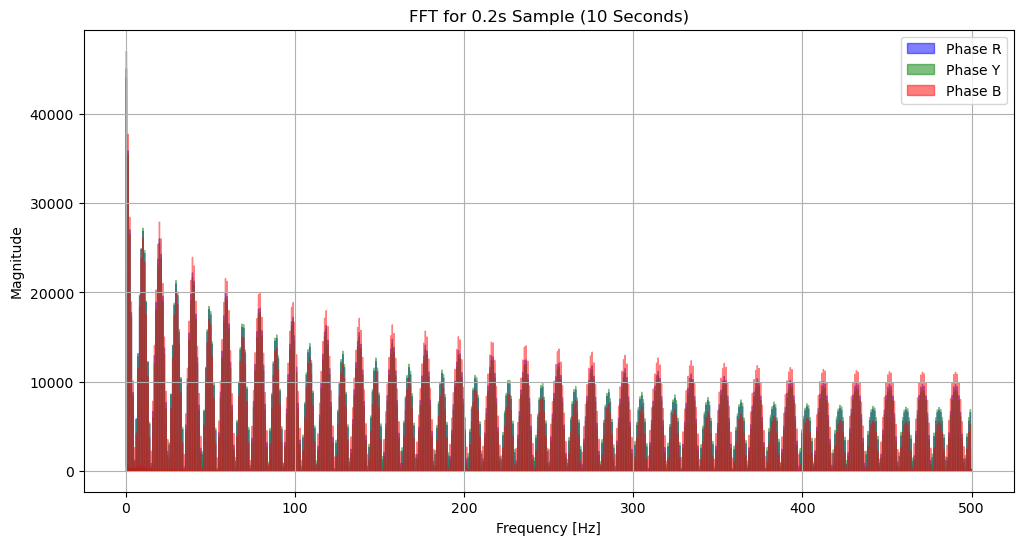

Plotting FFT for 0.5s...


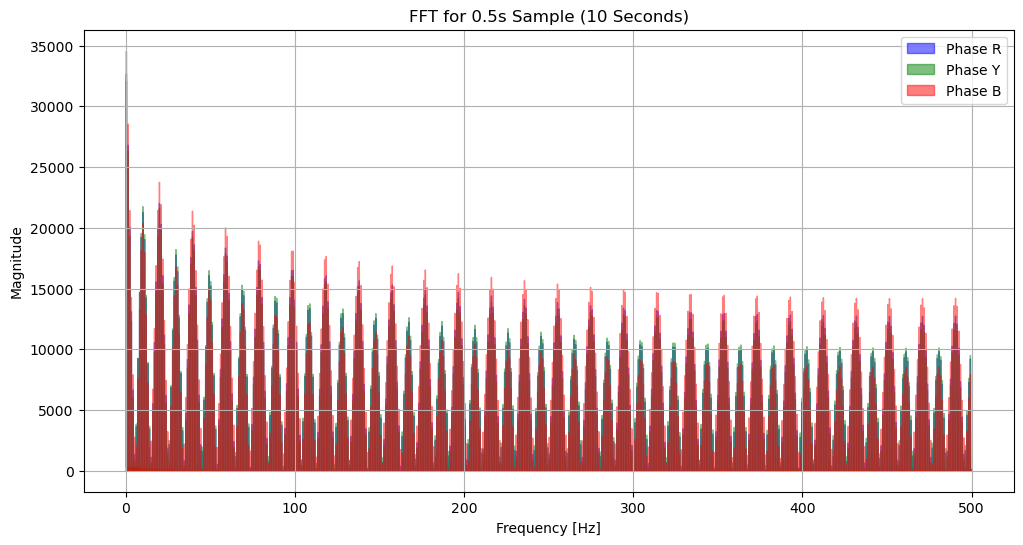

Plotting FFT for 1s...


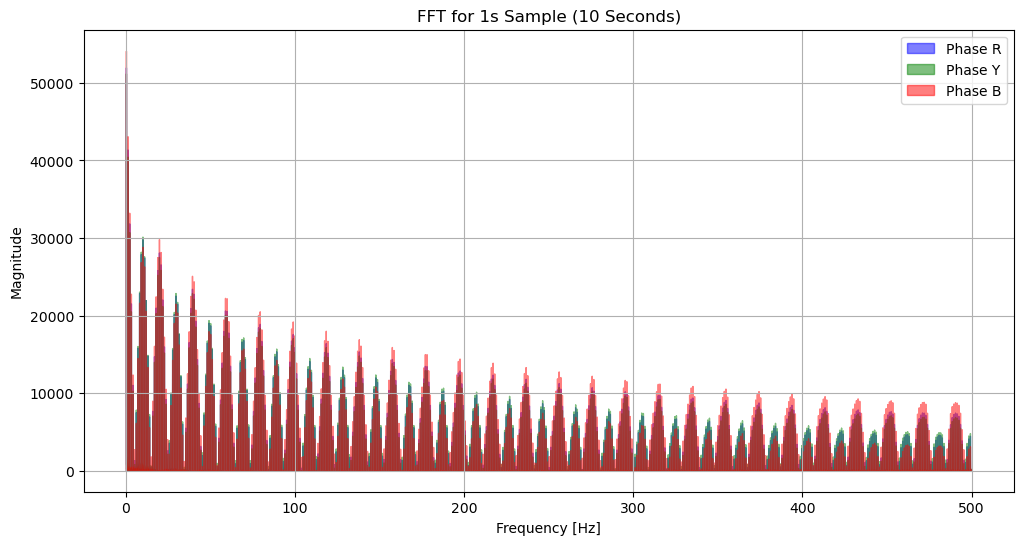

Plotting FFT for 2s...


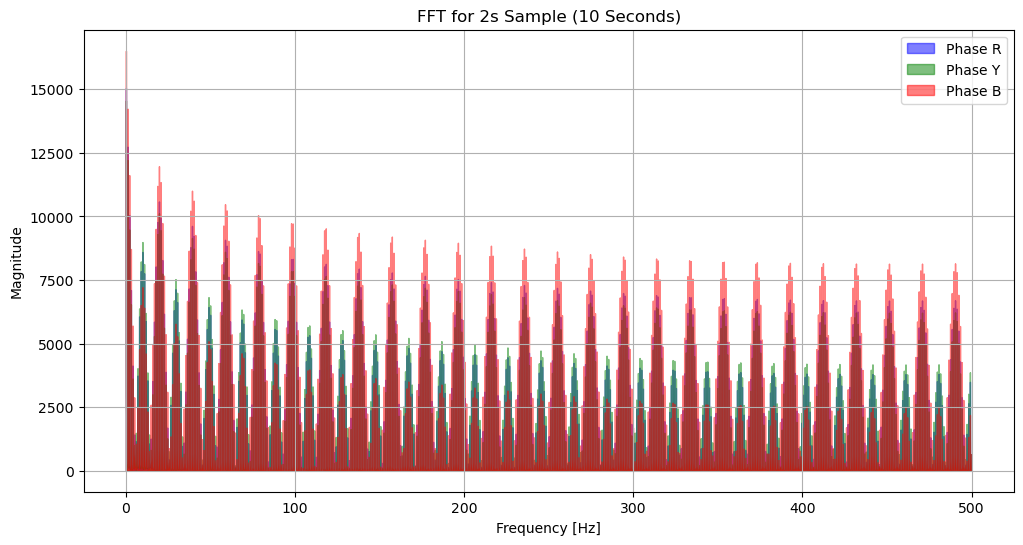

In [25]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft

def load_intermittent_fault_data(base_dir):
    """
    Load raw intermittent fault data from the specified directory.
    """
    intermittent_data = {}
    folders = ["0.2s", "0.5s", "1s", "2s"]

    for folder in folders:
        folder_path = os.path.join(base_dir, folder)
        if not os.path.exists(folder_path):
            print(f"Folder {folder_path} does not exist. Skipping.")
            continue

        for file in os.listdir(folder_path):
            if file.endswith(".csv"):
                file_path = os.path.join(folder_path, file)
                try:
                    # Load the CSV file
                    df = pd.read_csv(file_path, header=None)
                    current_data = df.iloc[:, -3:].values  # Take the last 3 columns (R, Y, B currents)

                    # Store the entire 10-second signal
                    if folder not in intermittent_data:
                        intermittent_data[folder] = []
                    intermittent_data[folder].append(current_data)

                except Exception as e:
                    print(f"Error processing file {file_path}: {e}")

    return intermittent_data

def plot_fft(signal, folder_name):
    """
    Plot the FFT of the entire 10-second signal with blue background and green window.
    """
    fs = 1000  # Sampling frequency (1 kHz)
    n = len(signal)  # Number of samples
    freq = np.fft.fftfreq(n, d=1/fs)  # Frequency axis
    fft_result = np.abs(fft(signal, axis=0))  # Compute FFT for each phase

    # Plot FFT for Phase R
    plt.figure(figsize=(12, 6))
    plt.fill_between(freq[:n//2], 0, fft_result[:n//2, 0], color='blue', alpha=0.5, label="Phase R")
    plt.fill_between(freq[:n//2], 0, fft_result[:n//2, 1], color='green', alpha=0.5, label="Phase Y")
    plt.fill_between(freq[:n//2], 0, fft_result[:n//2, 2], color='red', alpha=0.5, label="Phase B")
    plt.title(f"FFT for {folder_name} Sample (10 Seconds)")
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("Magnitude")
    plt.legend()
    plt.grid()
    plt.show()

# Directory path to intermittent fault data
intermittent_fault_dir = "/home/ani/Project/Interfault_coif1/B/"

# Load intermittent fault data
intermittent_data = load_intermittent_fault_data(intermittent_fault_dir)

# Check if data was loaded
if not intermittent_data:
    print("No intermittent fault data found! Check the directory structure and file paths.")
    exit()

# Plot FFT for one sample from each folder
for folder, data_list in intermittent_data.items():
    if data_list:  # Check if data exists for the folder
        print(f"Plotting FFT for {folder}...")
        sample = data_list[0]  # Take the first sample
        plot_fft(sample, folder)